### Invariant of neural representation

- build multivariate gaussian distribution with covariance matrix
- The covariance matrix is built by rotating the original covariance matrix
- The rotation is done by a design matrix B.



In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import pandas as pd
from sklearn.decomposition import PCA
from hebbian.utils import rotation_matrix_nd, rotate_cov_nd, eig_sorted, ellipse_xy_from_cov, instantiate_before_after_X, before_after_distribution

In [2]:
N = 10
m = 2
phi_deg = 45.0
n_samples = 10001
X_seed = 0
# get /sigma
Sigma = np.array([[1.0, 0.2], [0.2, 1.0]])
Sigma_rot = rotate_cov_nd(Sigma, np.deg2rad(phi_deg), axis1=0, axis2=1)

X_before, X_after = instantiate_before_after_X(Sigma, Sigma_rot, N = N, seed=X_seed, n_samples=n_samples)

# Do PCA on X before and X after
pca_before = PCA(n_components=m)
pca_before.fit(X_before)
X_before_pca = pca_before.transform(X_before)
pca_after = PCA(n_components=m)
pca_after.fit(X_after)
X_after_pca = pca_after.transform(X_after)

# eigen values of X before and X after
print(f"Eigen values of X before: {pca_before.explained_variance_}")
print(f"Eigen values of X after: {pca_after.explained_variance_}")

# variance explained by each PC
print(f"Variance explained by each PC of X before: {pca_before.explained_variance_ratio_}")
print(f"Variance explained by each PC of X after: {pca_after.explained_variance_ratio_}")



Eigen values of X before: [1.18832136 0.79510762]
Eigen values of X after: [1.22674947 0.80661225]
Variance explained by each PC of X before: [0.59912473 0.40087527]
Variance explained by each PC of X after: [0.60331099 0.39668901]


### Apply Leen's complete model to before and after drifted models

In [3]:
from hebbian.models import LeenCompletePCA
from hebbian.utils import Y_aligned_training_testing, Y_aligned_training_testing_online

In [4]:
# runs = 10
model_paras = dict(
    input_dim=N, output_dim=m,
    eta_w=5e-5,          # base
    eta_v=2e-3,          # ~4x eta_w
    C=2.0,
    ema_alpha=0.03,
    symmetrize_V=True,
    seed=None,
    noise_level=0.001,
    settling_steps=10
)

model_paras_after = dict(
    eta_w=5e-5,
    eta_v=2e-4,
#     eta_w=6e-5,          # base
#     eta_v=5e-4,          # ~4x eta_w
)

### Multiple runs

In [5]:
### Two phase training and testing

def bar_graph_with_error_bars(df_best_corr, title):
    figure = plt.figure()
    means = df_best_corr.mean(axis=0)
    stds = df_best_corr.std(axis=0)
    plt.figure(figsize=(10, 6))
    plt.bar(means.index, means.values, yerr=stds.values, capsize=5)
    plt.ylabel('Mean Absolute Correlation')
    plt.title(title)
    plt.show()

def two_phase_training_testing(model, data_before, data_after, m, model_paras_after=None, runs =10, graph = True):
    df_best_corr_after = pd.DataFrame(data=np.full((runs, m), np.nan), 
                            columns=[f"PC_{i+1}" for i in range(m)],
                            index=[f"run_{i+1}" for i in range(runs)])
    df_best_corr_before = pd.DataFrame(data=np.full((runs, m), np.nan), 
                            columns=[f"PC_{i+1}" for i in range(m)],
                            index=[f"run_{i+1}" for i in range(runs)])

    for run in range(runs):
        print(f"run {run+1:2d}")
        print(f"X_before")
        order, similarity = Y_aligned_training_testing_online(model, data_before, graph=True, alignment="cov")
        # print(f"After first phase: model.W = {model.W}, model.V: {model.V}")
        # print(f"Y_output_after_first_phase: {model.transform(data_before)}")
       # based on the order, sort the similarity to match PC order
        combined_lists = zip(order, similarity)
        # Sort the pairs based on PC_orders
        sorted_combined_lists = sorted(combined_lists)
        # Unzip the sorted pairs
        _, ordered_similarity = zip(*sorted_combined_lists)
        df_best_corr_before.iloc[run, :] = ordered_similarity 

#################################################################
        print(f"X_after")
        # update the model parameters, if provided
        if model_paras_after is not None:
            for key, value in model_paras_after.items():
                if hasattr(model, key):
                    setattr(model, key, value)

        order, similarity = Y_aligned_training_testing_online(model, data_after, graph=True, alignment="cosine")
        print(f"after second phase: model.W = {model.W}")
        try:
            print(f"model.V = {model.V}")
        except AttributeError:
            pass
        # based on the order, sort the similarity to match PC order
        combined_lists = zip(order, similarity)
        # Sort the pairs based on PC_orders
        sorted_combined_lists = sorted(combined_lists)
        # Unzip the sorted pairs
        _, ordered_similarity = zip(*sorted_combined_lists)
        df_best_corr_after.iloc[run, :] = ordered_similarity
        # print(f"run {run+1:2d} | order = {order} | best|corr|= {np.round(similarity,3)}")
        model.reset()

    if graph == True:
        bar_graph_with_error_bars(df_best_corr_before, "Mean Absolute Correlation (before)")
        bar_graph_with_error_bars(df_best_corr_after, "Mean Absolute Correlation (after)")

### Golden standard: Sanger's rule

run  1
X_before
step    0 | order = [0 1] | best|corr|= [0.001 0.001]
step 1000 | order = [1 0] | best|corr|= [0.236 0.327]
step 2000 | order = [1 0] | best|corr|= [0.236 0.37 ]
step 3000 | order = [1 0] | best|corr|= [0.233 0.371]
step 4000 | order = [1 0] | best|corr|= [0.236 0.356]
step 5000 | order = [1 0] | best|corr|= [0.237 0.357]
step 6000 | order = [1 0] | best|corr|= [0.231 0.344]
step 7000 | order = [1 0] | best|corr|= [0.234 0.349]
step 8000 | order = [1 0] | best|corr|= [0.236 0.366]
step 9000 | order = [1 0] | best|corr|= [0.233 0.347]
step 10000 | order = [1 0] | best|corr|= [0.235 0.366]


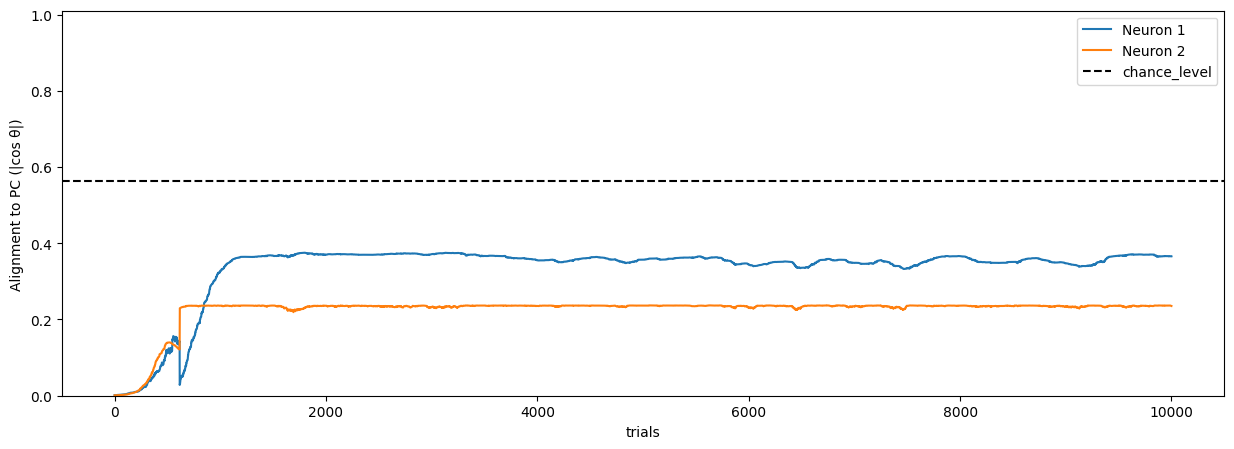

X_after
step    0 | order = [1 0] | best|corr|= [0.941 0.984]
step 1000 | order = [0 1] | best|corr|= [0.876 0.743]
step 2000 | order = [0 1] | best|corr|= [0.799 0.691]
step 3000 | order = [0 1] | best|corr|= [0.882 0.845]
step 4000 | order = [1 0] | best|corr|= [0.726 0.694]
step 5000 | order = [0 1] | best|corr|= [0.931 0.971]
step 6000 | order = [0 1] | best|corr|= [0.843 0.772]
step 7000 | order = [0 1] | best|corr|= [0.815 0.83 ]
step 8000 | order = [0 1] | best|corr|= [0.882 0.791]
step 9000 | order = [0 1] | best|corr|= [0.84  0.754]
step 10000 | order = [0 1] | best|corr|= [0.81  0.842]


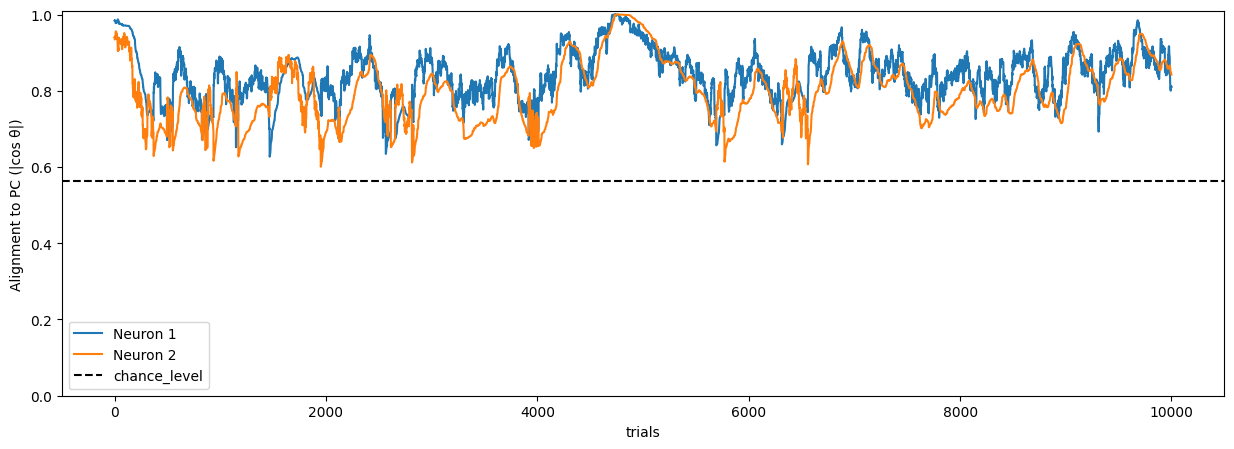

after second phase: model.W = [[-0.31295296 -0.37765478  0.26929332  0.0015504   0.48998653  0.61308453
  -0.01058892  0.52435003 -0.0226277  -0.91217452]
 [-0.22928626 -0.60808525 -0.64135171  0.18109697 -0.19482267 -0.19056535
   0.49992405 -0.46889362  0.33255917 -0.67619502]]
run  2
X_before
step    0 | order = [0 1] | best|corr|= [0.003 0.001]
step 1000 | order = [1 0] | best|corr|= [0.333 0.518]
step 2000 | order = [1 0] | best|corr|= [0.335 0.518]
step 3000 | order = [1 0] | best|corr|= [0.323 0.524]
step 4000 | order = [1 0] | best|corr|= [0.332 0.495]
step 5000 | order = [1 0] | best|corr|= [0.335 0.512]
step 6000 | order = [1 0] | best|corr|= [0.316 0.459]
step 7000 | order = [1 0] | best|corr|= [0.33  0.477]
step 8000 | order = [1 0] | best|corr|= [0.335 0.519]
step 9000 | order = [1 0] | best|corr|= [0.323 0.472]
step 10000 | order = [1 0] | best|corr|= [0.332 0.51 ]


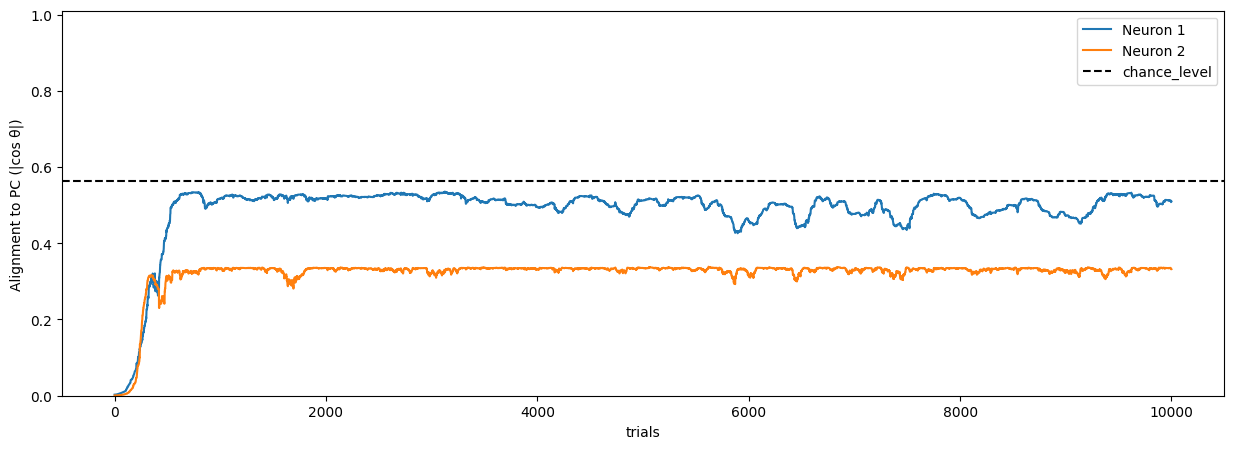

X_after
step    0 | order = [1 0] | best|corr|= [0.928 0.989]
step 1000 | order = [0 1] | best|corr|= [0.876 0.743]
step 2000 | order = [0 1] | best|corr|= [0.799 0.691]
step 3000 | order = [0 1] | best|corr|= [0.882 0.845]
step 4000 | order = [1 0] | best|corr|= [0.726 0.694]
step 5000 | order = [0 1] | best|corr|= [0.931 0.971]
step 6000 | order = [0 1] | best|corr|= [0.843 0.772]
step 7000 | order = [0 1] | best|corr|= [0.815 0.83 ]
step 8000 | order = [0 1] | best|corr|= [0.882 0.791]
step 9000 | order = [0 1] | best|corr|= [0.84  0.754]
step 10000 | order = [0 1] | best|corr|= [0.81  0.842]


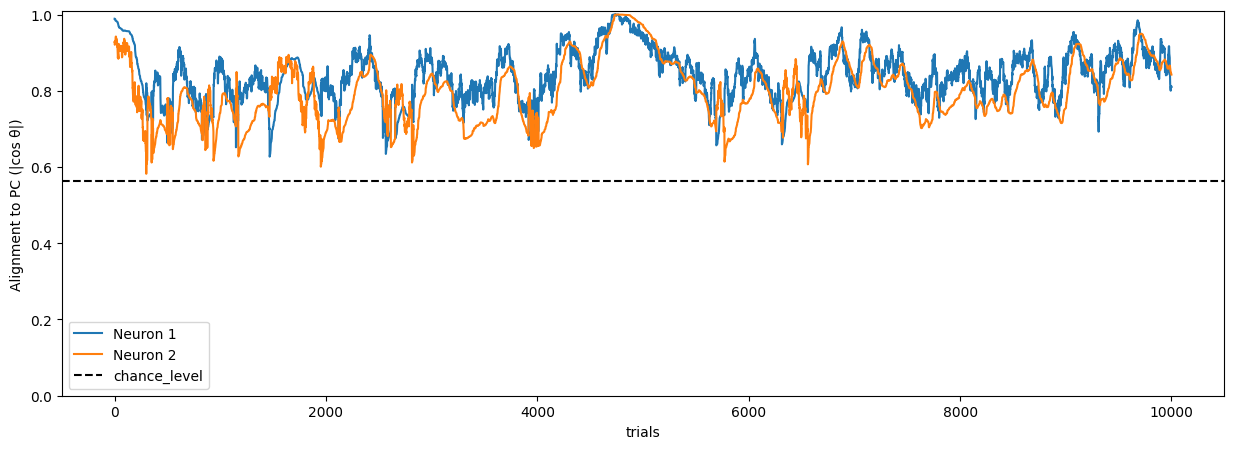

after second phase: model.W = [[-0.31295296 -0.37765478  0.26929332  0.0015504   0.48998653  0.61308453
  -0.01058892  0.52435003 -0.0226277  -0.91217452]
 [ 0.22928626  0.60808525  0.64135171 -0.18109697  0.19482267  0.19056535
  -0.49992405  0.46889362 -0.33255917  0.67619502]]
run  3
X_before
step    0 | order = [0 1] | best|corr|= [0.005 0.001]
step 1000 | order = [1 0] | best|corr|= [0.333 0.516]
step 2000 | order = [1 0] | best|corr|= [0.335 0.518]
step 3000 | order = [1 0] | best|corr|= [0.323 0.524]
step 4000 | order = [1 0] | best|corr|= [0.332 0.495]
step 5000 | order = [1 0] | best|corr|= [0.335 0.512]
step 6000 | order = [1 0] | best|corr|= [0.316 0.459]
step 7000 | order = [1 0] | best|corr|= [0.33  0.477]
step 8000 | order = [1 0] | best|corr|= [0.335 0.519]
step 9000 | order = [1 0] | best|corr|= [0.323 0.472]
step 10000 | order = [1 0] | best|corr|= [0.332 0.51 ]


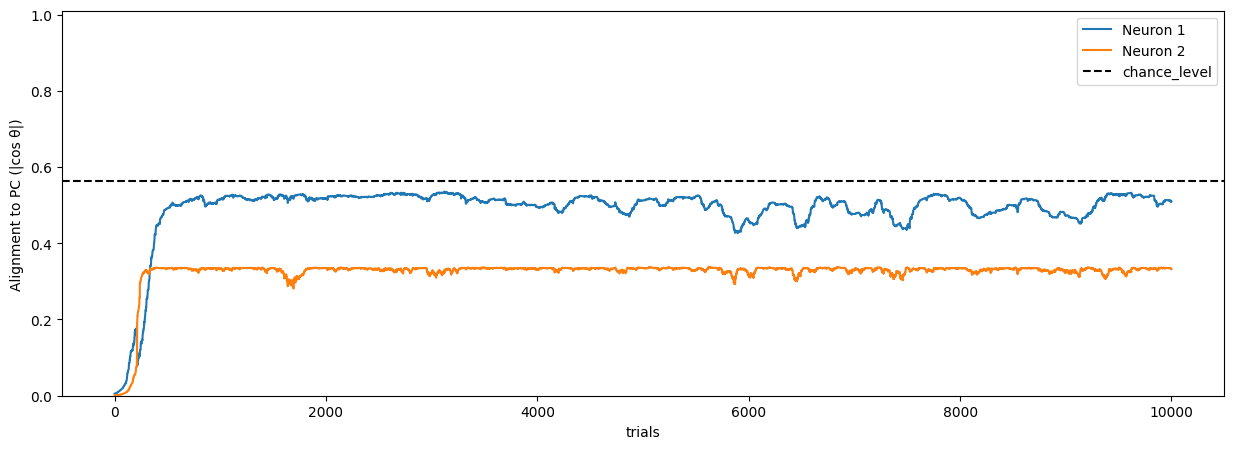

X_after
step    0 | order = [1 0] | best|corr|= [0.928 0.989]
step 1000 | order = [0 1] | best|corr|= [0.876 0.743]
step 2000 | order = [0 1] | best|corr|= [0.799 0.691]
step 3000 | order = [0 1] | best|corr|= [0.882 0.845]
step 4000 | order = [1 0] | best|corr|= [0.726 0.694]
step 5000 | order = [0 1] | best|corr|= [0.931 0.971]
step 6000 | order = [0 1] | best|corr|= [0.843 0.772]
step 7000 | order = [0 1] | best|corr|= [0.815 0.83 ]
step 8000 | order = [0 1] | best|corr|= [0.882 0.791]
step 9000 | order = [0 1] | best|corr|= [0.84  0.754]
step 10000 | order = [0 1] | best|corr|= [0.81  0.842]


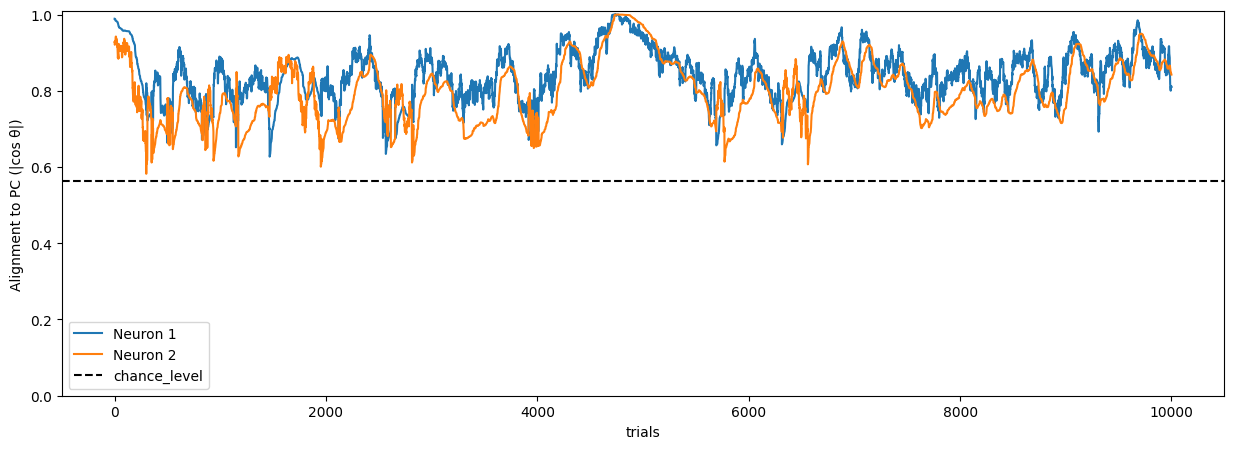

after second phase: model.W = [[ 0.31295296  0.37765478 -0.26929332 -0.0015504  -0.48998653 -0.61308453
   0.01058892 -0.52435003  0.0226277   0.91217452]
 [-0.22928626 -0.60808525 -0.64135171  0.18109697 -0.19482267 -0.19056535
   0.49992405 -0.46889362  0.33255917 -0.67619502]]
run  4
X_before
step    0 | order = [1 0] | best|corr|= [0.    0.001]
step 1000 | order = [1 0] | best|corr|= [0.333 0.516]
step 2000 | order = [1 0] | best|corr|= [0.335 0.518]
step 3000 | order = [1 0] | best|corr|= [0.323 0.524]
step 4000 | order = [1 0] | best|corr|= [0.332 0.495]
step 5000 | order = [1 0] | best|corr|= [0.335 0.512]
step 6000 | order = [1 0] | best|corr|= [0.316 0.459]
step 7000 | order = [1 0] | best|corr|= [0.33  0.477]
step 8000 | order = [1 0] | best|corr|= [0.335 0.519]
step 9000 | order = [1 0] | best|corr|= [0.323 0.472]
step 10000 | order = [1 0] | best|corr|= [0.332 0.51 ]


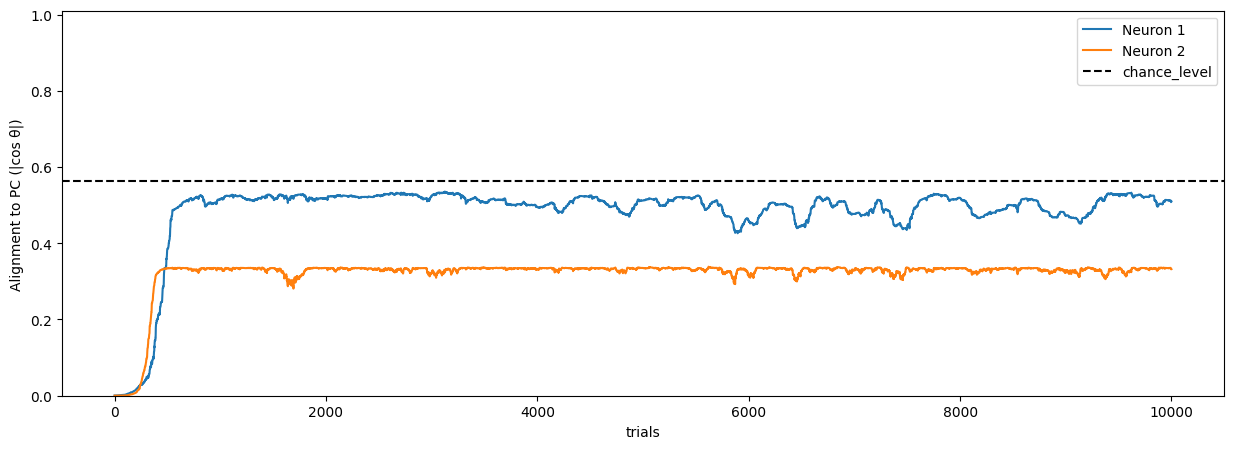

X_after
step    0 | order = [1 0] | best|corr|= [0.928 0.989]
step 1000 | order = [0 1] | best|corr|= [0.876 0.743]
step 2000 | order = [0 1] | best|corr|= [0.799 0.691]
step 3000 | order = [0 1] | best|corr|= [0.882 0.845]
step 4000 | order = [1 0] | best|corr|= [0.726 0.694]
step 5000 | order = [0 1] | best|corr|= [0.931 0.971]
step 6000 | order = [0 1] | best|corr|= [0.843 0.772]
step 7000 | order = [0 1] | best|corr|= [0.815 0.83 ]
step 8000 | order = [0 1] | best|corr|= [0.882 0.791]
step 9000 | order = [0 1] | best|corr|= [0.84  0.754]
step 10000 | order = [0 1] | best|corr|= [0.81  0.842]


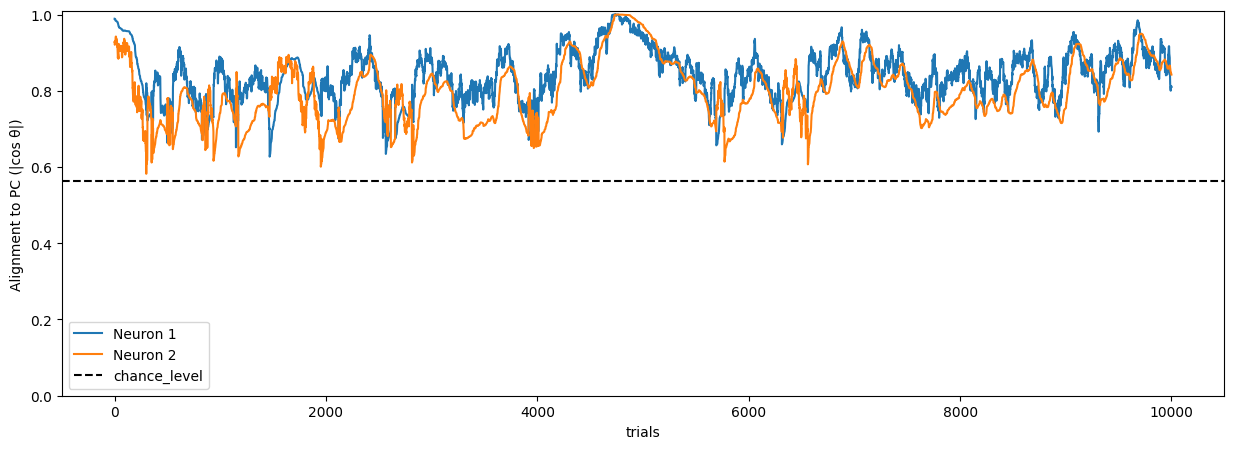

after second phase: model.W = [[ 0.31295296  0.37765478 -0.26929332 -0.0015504  -0.48998653 -0.61308453
   0.01058892 -0.52435003  0.0226277   0.91217452]
 [-0.22928626 -0.60808525 -0.64135171  0.18109697 -0.19482267 -0.19056535
   0.49992405 -0.46889362  0.33255917 -0.67619502]]
run  5
X_before
step    0 | order = [1 0] | best|corr|= [0.004 0.002]
step 1000 | order = [1 0] | best|corr|= [0.333 0.516]
step 2000 | order = [1 0] | best|corr|= [0.335 0.518]
step 3000 | order = [1 0] | best|corr|= [0.323 0.524]
step 4000 | order = [1 0] | best|corr|= [0.332 0.495]
step 5000 | order = [1 0] | best|corr|= [0.335 0.512]
step 6000 | order = [1 0] | best|corr|= [0.316 0.459]
step 7000 | order = [1 0] | best|corr|= [0.33  0.477]
step 8000 | order = [1 0] | best|corr|= [0.335 0.519]
step 9000 | order = [1 0] | best|corr|= [0.323 0.472]
step 10000 | order = [1 0] | best|corr|= [0.332 0.51 ]


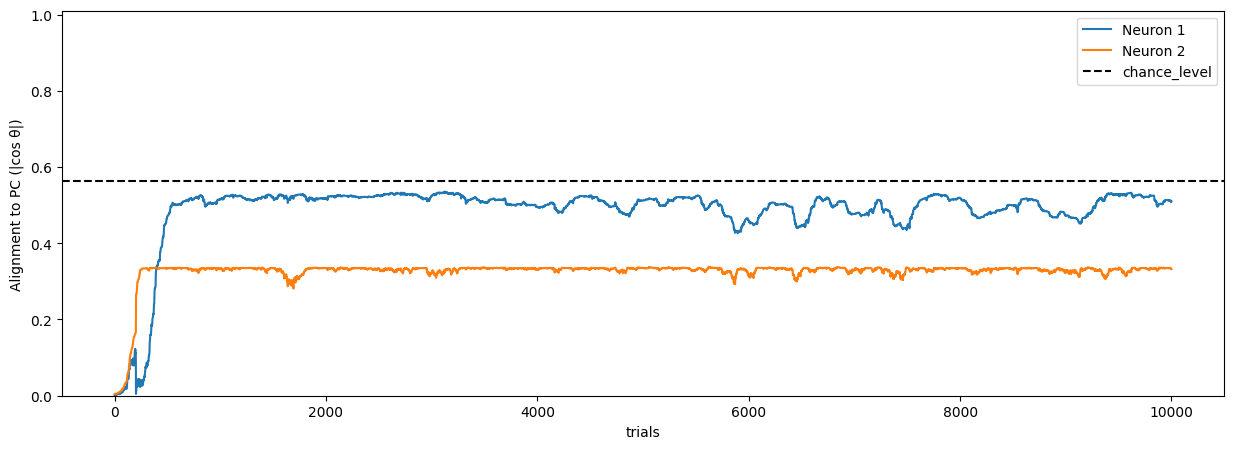

X_after
step    0 | order = [1 0] | best|corr|= [0.928 0.989]
step 1000 | order = [0 1] | best|corr|= [0.876 0.743]
step 2000 | order = [0 1] | best|corr|= [0.799 0.691]
step 3000 | order = [0 1] | best|corr|= [0.882 0.845]
step 4000 | order = [1 0] | best|corr|= [0.726 0.694]
step 5000 | order = [0 1] | best|corr|= [0.931 0.971]
step 6000 | order = [0 1] | best|corr|= [0.843 0.772]
step 7000 | order = [0 1] | best|corr|= [0.815 0.83 ]
step 8000 | order = [0 1] | best|corr|= [0.882 0.791]
step 9000 | order = [0 1] | best|corr|= [0.84  0.754]
step 10000 | order = [0 1] | best|corr|= [0.81  0.842]


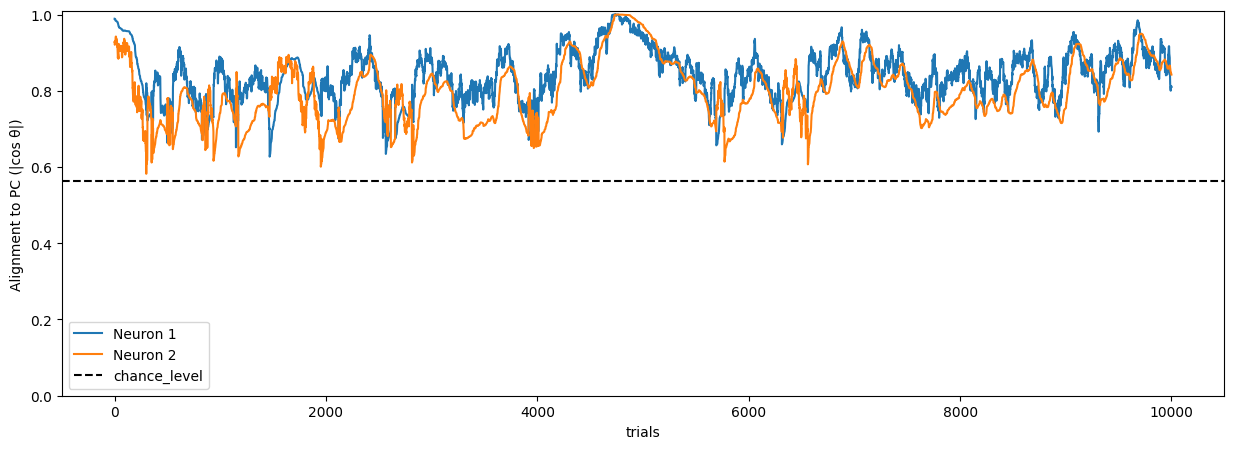

after second phase: model.W = [[-0.31295296 -0.37765478  0.26929332  0.0015504   0.48998653  0.61308453
  -0.01058892  0.52435003 -0.0226277  -0.91217452]
 [-0.22928626 -0.60808525 -0.64135171  0.18109697 -0.19482267 -0.19056535
   0.49992405 -0.46889362  0.33255917 -0.67619502]]
run  6
X_before
step    0 | order = [1 0] | best|corr|= [0.003 0.007]
step 1000 | order = [1 0] | best|corr|= [0.333 0.516]
step 2000 | order = [1 0] | best|corr|= [0.335 0.518]
step 3000 | order = [1 0] | best|corr|= [0.323 0.524]
step 4000 | order = [1 0] | best|corr|= [0.332 0.495]
step 5000 | order = [1 0] | best|corr|= [0.335 0.512]
step 6000 | order = [1 0] | best|corr|= [0.316 0.459]
step 7000 | order = [1 0] | best|corr|= [0.33  0.477]
step 8000 | order = [1 0] | best|corr|= [0.335 0.519]
step 9000 | order = [1 0] | best|corr|= [0.323 0.472]
step 10000 | order = [1 0] | best|corr|= [0.332 0.51 ]


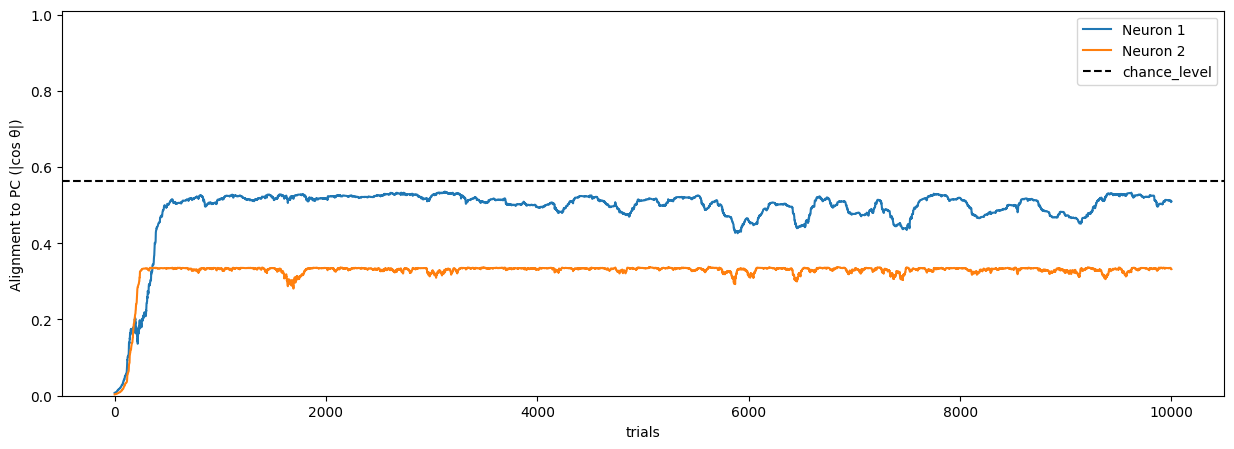

X_after
step    0 | order = [1 0] | best|corr|= [0.928 0.989]
step 1000 | order = [0 1] | best|corr|= [0.876 0.743]
step 2000 | order = [0 1] | best|corr|= [0.799 0.691]
step 3000 | order = [0 1] | best|corr|= [0.882 0.845]
step 4000 | order = [1 0] | best|corr|= [0.726 0.694]
step 5000 | order = [0 1] | best|corr|= [0.931 0.971]
step 6000 | order = [0 1] | best|corr|= [0.843 0.772]
step 7000 | order = [0 1] | best|corr|= [0.815 0.83 ]
step 8000 | order = [0 1] | best|corr|= [0.882 0.791]
step 9000 | order = [0 1] | best|corr|= [0.84  0.754]
step 10000 | order = [0 1] | best|corr|= [0.81  0.842]


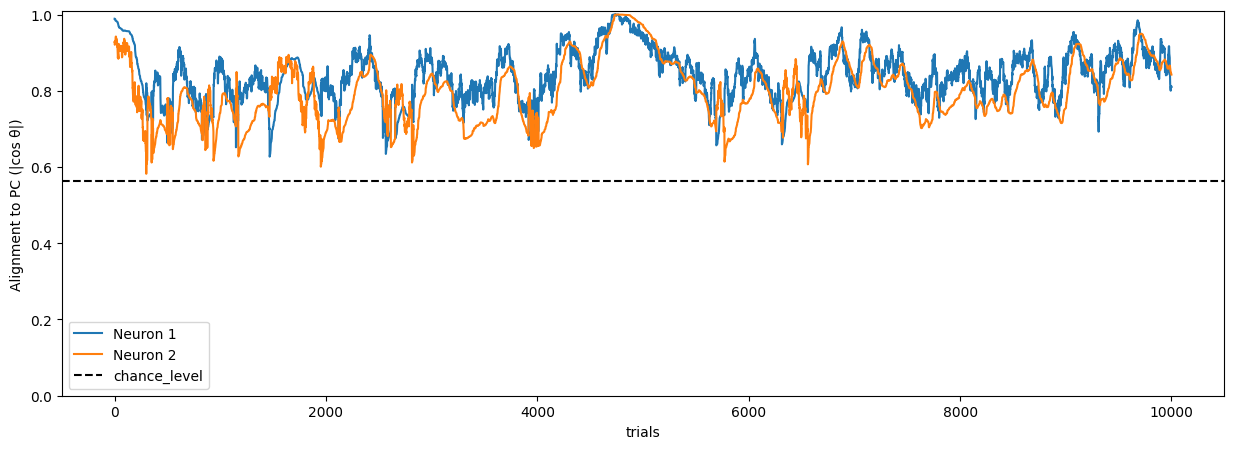

after second phase: model.W = [[ 0.31295296  0.37765478 -0.26929332 -0.0015504  -0.48998653 -0.61308453
   0.01058892 -0.52435003  0.0226277   0.91217452]
 [ 0.22928626  0.60808525  0.64135171 -0.18109697  0.19482267  0.19056535
  -0.49992405  0.46889362 -0.33255917  0.67619502]]
run  7
X_before
step    0 | order = [0 1] | best|corr|= [0.004 0.002]
step 1000 | order = [1 0] | best|corr|= [0.333 0.516]
step 2000 | order = [1 0] | best|corr|= [0.335 0.518]
step 3000 | order = [1 0] | best|corr|= [0.323 0.524]
step 4000 | order = [1 0] | best|corr|= [0.332 0.495]
step 5000 | order = [1 0] | best|corr|= [0.335 0.512]
step 6000 | order = [1 0] | best|corr|= [0.316 0.459]
step 7000 | order = [1 0] | best|corr|= [0.33  0.477]
step 8000 | order = [1 0] | best|corr|= [0.335 0.519]
step 9000 | order = [1 0] | best|corr|= [0.323 0.472]
step 10000 | order = [1 0] | best|corr|= [0.332 0.51 ]


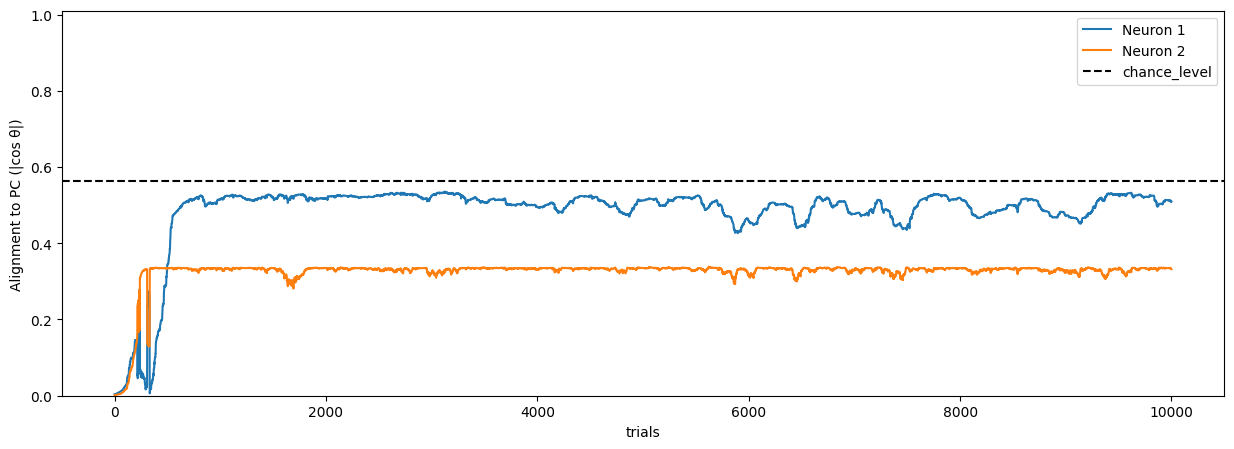

X_after
step    0 | order = [1 0] | best|corr|= [0.928 0.989]
step 1000 | order = [0 1] | best|corr|= [0.876 0.743]
step 2000 | order = [0 1] | best|corr|= [0.799 0.691]
step 3000 | order = [0 1] | best|corr|= [0.882 0.845]
step 4000 | order = [1 0] | best|corr|= [0.726 0.694]
step 5000 | order = [0 1] | best|corr|= [0.931 0.971]
step 6000 | order = [0 1] | best|corr|= [0.843 0.772]
step 7000 | order = [0 1] | best|corr|= [0.815 0.83 ]
step 8000 | order = [0 1] | best|corr|= [0.882 0.791]
step 9000 | order = [0 1] | best|corr|= [0.84  0.754]
step 10000 | order = [0 1] | best|corr|= [0.81  0.842]


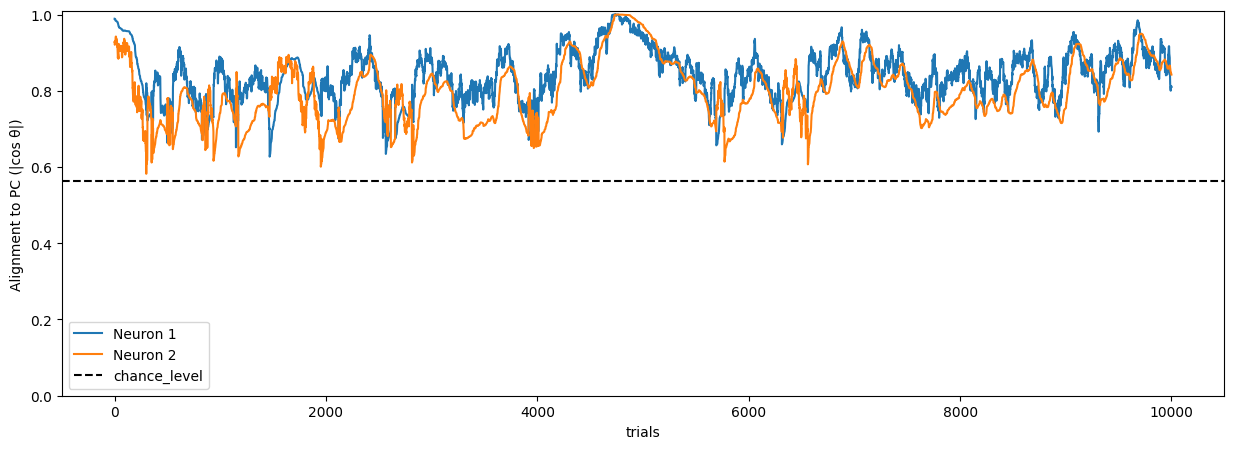

after second phase: model.W = [[-0.31295296 -0.37765478  0.26929332  0.0015504   0.48998653  0.61308453
  -0.01058892  0.52435003 -0.0226277  -0.91217452]
 [-0.22928626 -0.60808525 -0.64135171  0.18109697 -0.19482267 -0.19056535
   0.49992405 -0.46889362  0.33255917 -0.67619502]]
run  8
X_before
step    0 | order = [0 1] | best|corr|= [0.003 0.001]
step 1000 | order = [1 0] | best|corr|= [0.333 0.516]
step 2000 | order = [1 0] | best|corr|= [0.335 0.518]
step 3000 | order = [1 0] | best|corr|= [0.323 0.524]
step 4000 | order = [1 0] | best|corr|= [0.332 0.495]
step 5000 | order = [1 0] | best|corr|= [0.335 0.512]
step 6000 | order = [1 0] | best|corr|= [0.316 0.459]
step 7000 | order = [1 0] | best|corr|= [0.33  0.477]
step 8000 | order = [1 0] | best|corr|= [0.335 0.519]
step 9000 | order = [1 0] | best|corr|= [0.323 0.472]
step 10000 | order = [1 0] | best|corr|= [0.332 0.51 ]


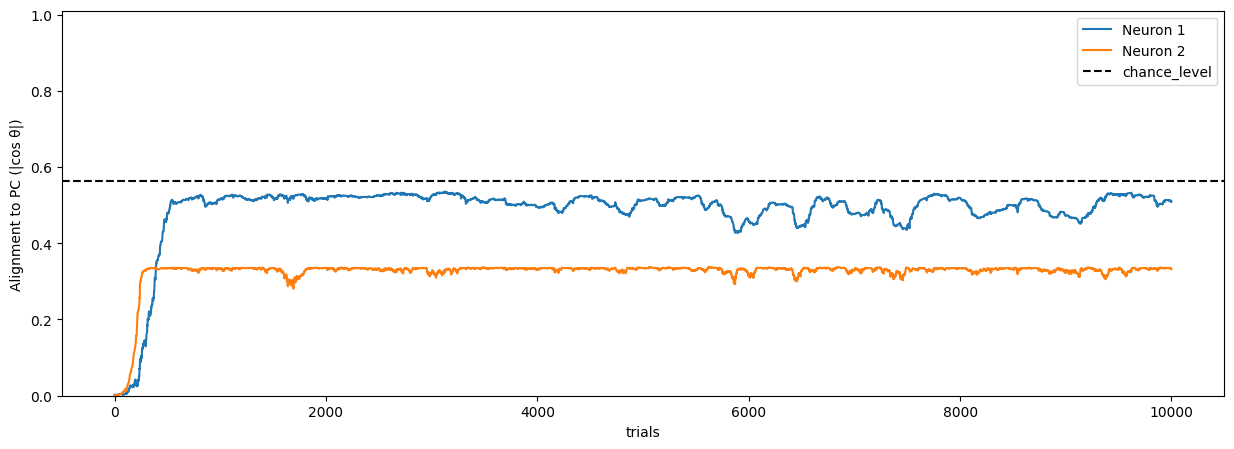

X_after
step    0 | order = [1 0] | best|corr|= [0.928 0.989]
step 1000 | order = [0 1] | best|corr|= [0.876 0.743]
step 2000 | order = [0 1] | best|corr|= [0.799 0.691]
step 3000 | order = [0 1] | best|corr|= [0.882 0.845]
step 4000 | order = [1 0] | best|corr|= [0.726 0.694]
step 5000 | order = [0 1] | best|corr|= [0.931 0.971]
step 6000 | order = [0 1] | best|corr|= [0.843 0.772]
step 7000 | order = [0 1] | best|corr|= [0.815 0.83 ]
step 8000 | order = [0 1] | best|corr|= [0.882 0.791]
step 9000 | order = [0 1] | best|corr|= [0.84  0.754]
step 10000 | order = [0 1] | best|corr|= [0.81  0.842]


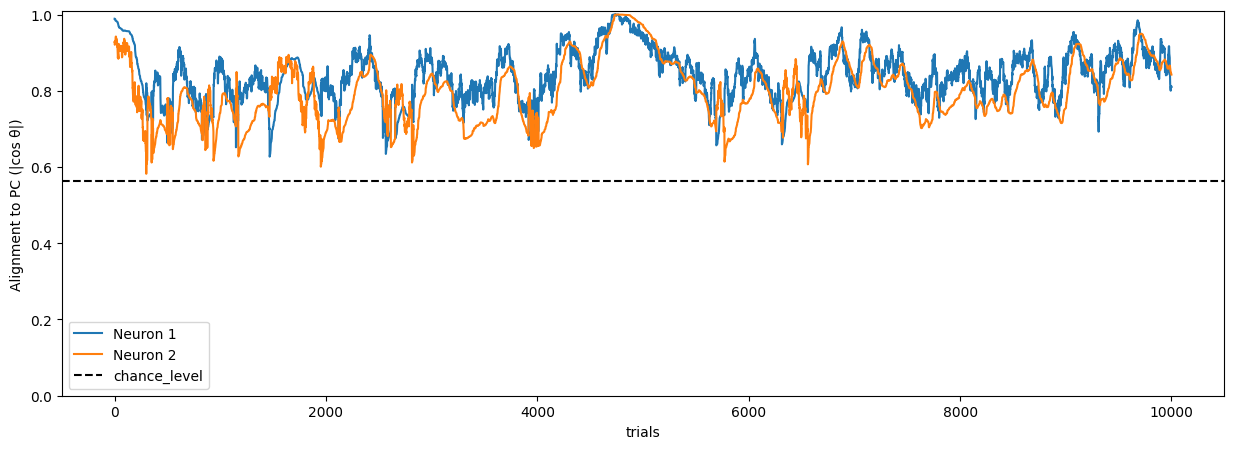

after second phase: model.W = [[-0.31295296 -0.37765478  0.26929332  0.0015504   0.48998653  0.61308453
  -0.01058892  0.52435003 -0.0226277  -0.91217452]
 [-0.22928626 -0.60808525 -0.64135171  0.18109697 -0.19482267 -0.19056535
   0.49992405 -0.46889362  0.33255917 -0.67619502]]
run  9
X_before
step    0 | order = [0 1] | best|corr|= [0.003 0.003]
step 1000 | order = [1 0] | best|corr|= [0.333 0.516]
step 2000 | order = [1 0] | best|corr|= [0.335 0.518]
step 3000 | order = [1 0] | best|corr|= [0.323 0.524]
step 4000 | order = [1 0] | best|corr|= [0.332 0.495]
step 5000 | order = [1 0] | best|corr|= [0.335 0.512]
step 6000 | order = [1 0] | best|corr|= [0.316 0.459]
step 7000 | order = [1 0] | best|corr|= [0.33  0.477]
step 8000 | order = [1 0] | best|corr|= [0.335 0.519]
step 9000 | order = [1 0] | best|corr|= [0.323 0.472]
step 10000 | order = [1 0] | best|corr|= [0.332 0.51 ]


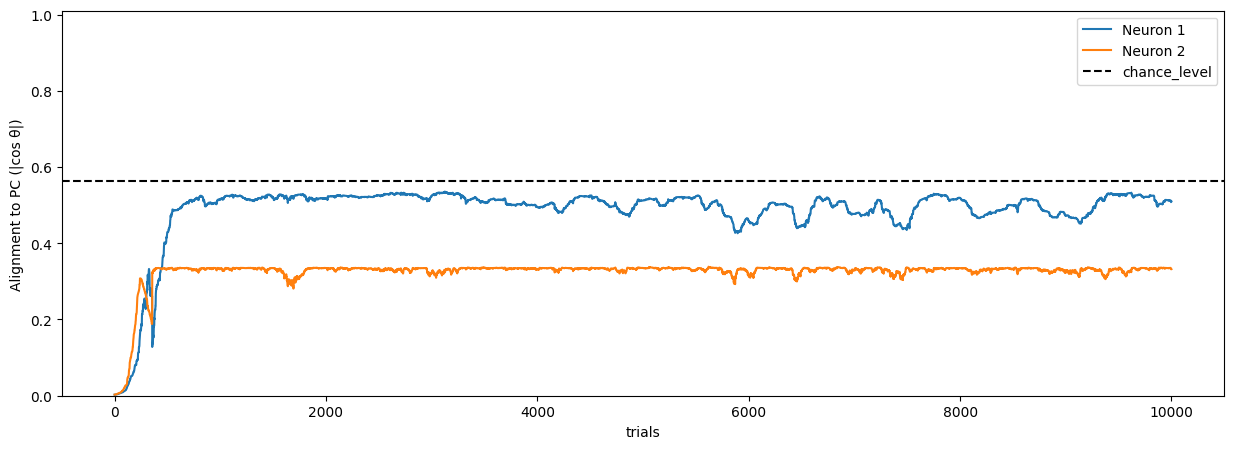

X_after
step    0 | order = [1 0] | best|corr|= [0.928 0.989]
step 1000 | order = [0 1] | best|corr|= [0.876 0.743]
step 2000 | order = [0 1] | best|corr|= [0.799 0.691]
step 3000 | order = [0 1] | best|corr|= [0.882 0.845]
step 4000 | order = [1 0] | best|corr|= [0.726 0.694]
step 5000 | order = [0 1] | best|corr|= [0.931 0.971]
step 6000 | order = [0 1] | best|corr|= [0.843 0.772]
step 7000 | order = [0 1] | best|corr|= [0.815 0.83 ]
step 8000 | order = [0 1] | best|corr|= [0.882 0.791]
step 9000 | order = [0 1] | best|corr|= [0.84  0.754]
step 10000 | order = [0 1] | best|corr|= [0.81  0.842]


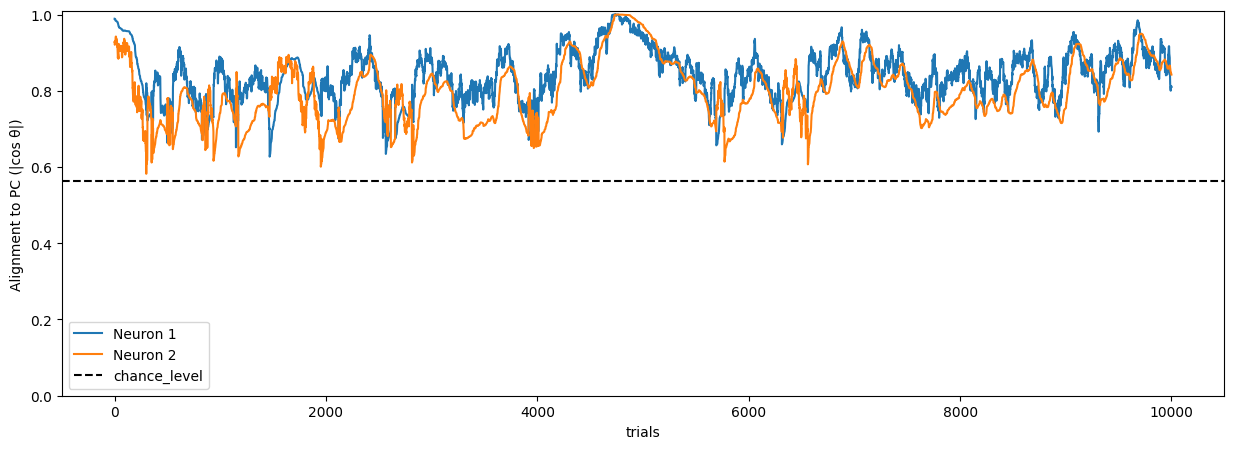

after second phase: model.W = [[ 0.31295296  0.37765478 -0.26929332 -0.0015504  -0.48998653 -0.61308453
   0.01058892 -0.52435003  0.0226277   0.91217452]
 [ 0.22928626  0.60808525  0.64135171 -0.18109697  0.19482267  0.19056535
  -0.49992405  0.46889362 -0.33255917  0.67619502]]
run 10
X_before
step    0 | order = [0 1] | best|corr|= [0.007 0.001]
step 1000 | order = [1 0] | best|corr|= [0.333 0.516]
step 2000 | order = [1 0] | best|corr|= [0.335 0.518]
step 3000 | order = [1 0] | best|corr|= [0.323 0.524]
step 4000 | order = [1 0] | best|corr|= [0.332 0.495]
step 5000 | order = [1 0] | best|corr|= [0.335 0.512]
step 6000 | order = [1 0] | best|corr|= [0.316 0.459]
step 7000 | order = [1 0] | best|corr|= [0.33  0.477]
step 8000 | order = [1 0] | best|corr|= [0.335 0.519]
step 9000 | order = [1 0] | best|corr|= [0.323 0.472]
step 10000 | order = [1 0] | best|corr|= [0.332 0.51 ]


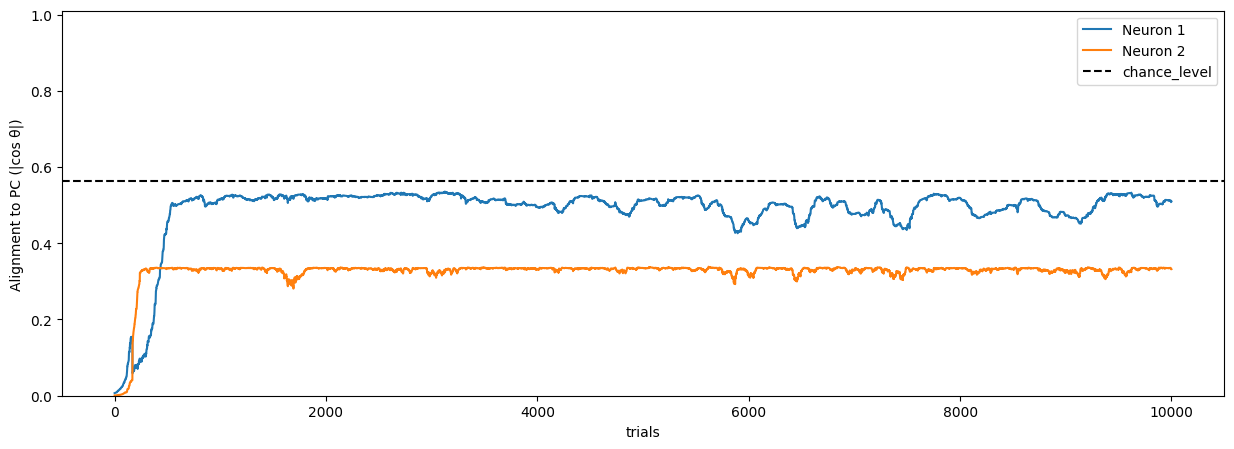

X_after
step    0 | order = [1 0] | best|corr|= [0.928 0.989]
step 1000 | order = [0 1] | best|corr|= [0.876 0.743]
step 2000 | order = [0 1] | best|corr|= [0.799 0.691]
step 3000 | order = [0 1] | best|corr|= [0.882 0.845]
step 4000 | order = [1 0] | best|corr|= [0.726 0.694]
step 5000 | order = [0 1] | best|corr|= [0.931 0.971]
step 6000 | order = [0 1] | best|corr|= [0.843 0.772]
step 7000 | order = [0 1] | best|corr|= [0.815 0.83 ]
step 8000 | order = [0 1] | best|corr|= [0.882 0.791]
step 9000 | order = [0 1] | best|corr|= [0.84  0.754]
step 10000 | order = [0 1] | best|corr|= [0.81  0.842]


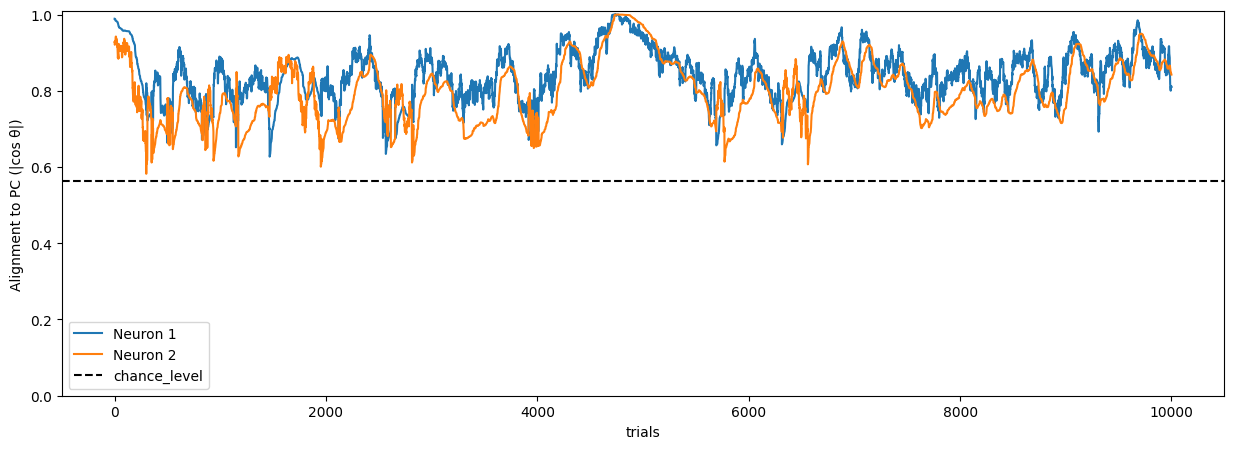

after second phase: model.W = [[-0.31295296 -0.37765478  0.26929332  0.0015504   0.48998653  0.61308453
  -0.01058892  0.52435003 -0.0226277  -0.91217452]
 [ 0.22928626  0.60808525  0.64135171 -0.18109697  0.19482267  0.19056535
  -0.49992405  0.46889362 -0.33255917  0.67619502]]


<Figure size 640x480 with 0 Axes>

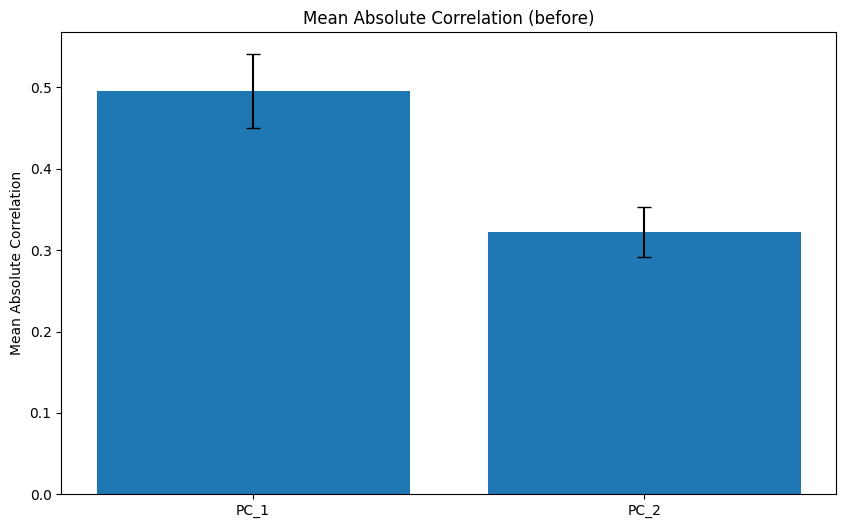

<Figure size 640x480 with 0 Axes>

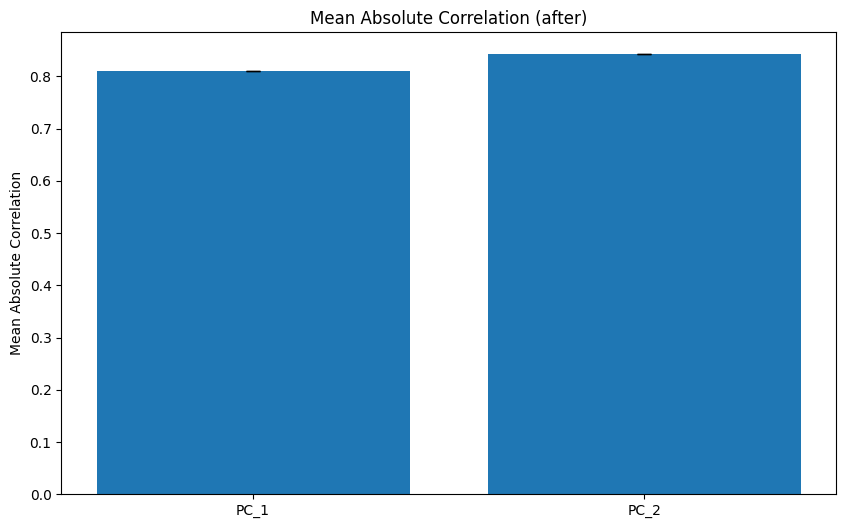

In [6]:
from hebbian.models import SangerNetwork
sanger_model = SangerNetwork(output_size=m, learning_rate=0.01)

sanger_model_after = dict(learning_rate=0.02)

two_phase_training_testing(sanger_model, X_before, X_after, m, model_paras_after = sanger_model_after, runs = 10, graph = True)

run  1
X_before
step    0 | order = [1 0] | best|corr|= [0.158 0.206]
step 1000 | order = [1 0] | best|corr|= [0.164 0.221]
step 2000 | order = [1 0] | best|corr|= [0.17  0.231]
step 3000 | order = [1 0] | best|corr|= [0.176 0.241]
step 4000 | order = [1 0] | best|corr|= [0.179 0.235]
step 5000 | order = [1 0] | best|corr|= [0.183 0.24 ]
step 6000 | order = [1 0] | best|corr|= [0.187 0.242]
step 7000 | order = [1 0] | best|corr|= [0.191 0.248]
step 8000 | order = [1 0] | best|corr|= [0.195 0.257]
step 9000 | order = [1 0] | best|corr|= [0.198 0.257]
step 10000 | order = [1 0] | best|corr|= [0.202 0.27 ]


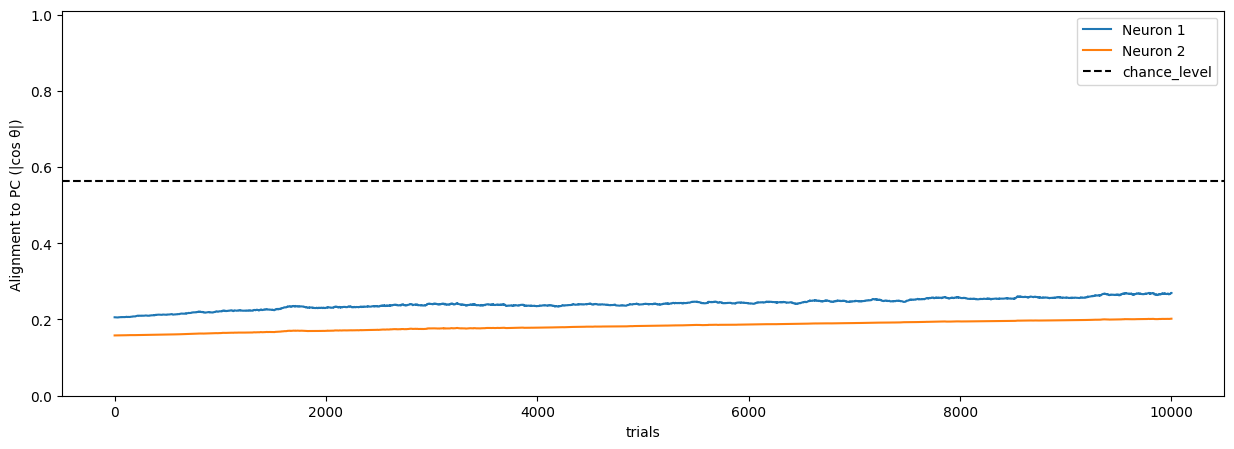

X_after
step    0 | order = [1 0] | best|corr|= [0.982 0.982]
step 1000 | order = [1 0] | best|corr|= [1.    0.907]
step 2000 | order = [1 0] | best|corr|= [0.998 0.93 ]
step 3000 | order = [1 0] | best|corr|= [0.999 0.918]
step 4000 | order = [1 0] | best|corr|= [0.996 0.942]
step 5000 | order = [1 0] | best|corr|= [0.996 0.948]
step 6000 | order = [1 0] | best|corr|= [1.    0.915]
step 7000 | order = [1 0] | best|corr|= [0.999 0.926]
step 8000 | order = [1 0] | best|corr|= [0.998 0.938]
step 9000 | order = [1 0] | best|corr|= [1.    0.904]
step 10000 | order = [1 0] | best|corr|= [0.997 0.943]


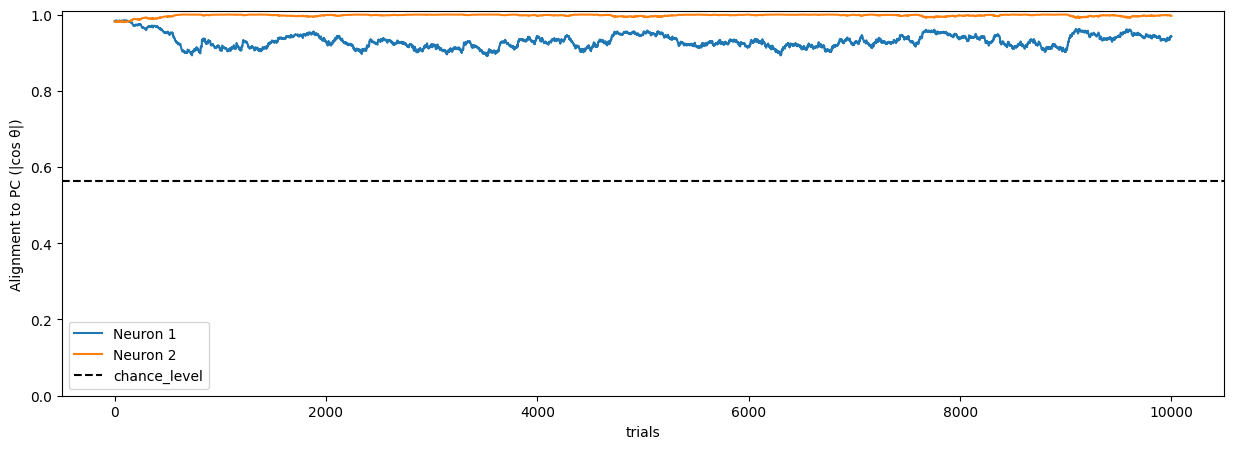

after second phase: model.W = [[ 0.24049162  0.18078603  0.09224296 -0.12028938 -0.19331645 -0.08728007
  -0.32074314 -0.00673589 -0.14043933  0.82992052]
 [ 0.0802743  -0.2147124   0.4043212  -0.25389462  0.50451471  0.37092079
  -0.26793426  0.45532238 -0.07731516  0.09710409]]
model.V = [[0.         0.19538898]
 [0.19538898 0.        ]]
run  2
X_before
step    0 | order = [1 0] | best|corr|= [0.136 0.297]
step 1000 | order = [1 0] | best|corr|= [0.018 0.535]
step 2000 | order = [1 0] | best|corr|= [0.009 0.574]
step 3000 | order = [1 0] | best|corr|= [0.017 0.55 ]
step 4000 | order = [1 0] | best|corr|= [0.035 0.516]
step 5000 | order = [1 0] | best|corr|= [0.037 0.549]
step 6000 | order = [1 0] | best|corr|= [0.057 0.458]
step 7000 | order = [1 0] | best|corr|= [0.062 0.462]
step 8000 | order = [1 0] | best|corr|= [0.069 0.451]
step 9000 | order = [1 0] | best|corr|= [0.076 0.407]
step 10000 | order = [1 0] | best|corr|= [0.083 0.389]


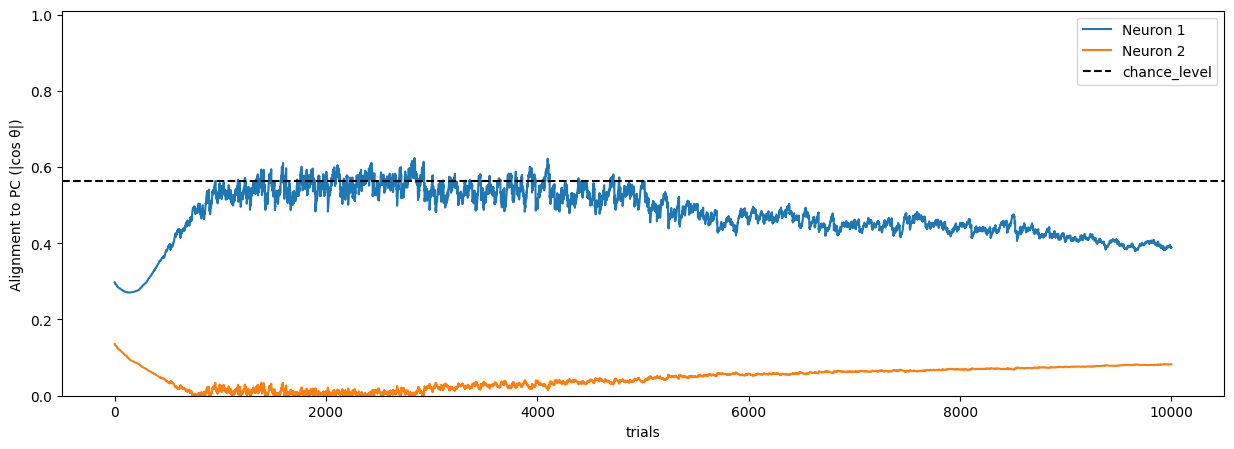

X_after
step    0 | order = [1 0] | best|corr|= [0.424 0.9  ]
step 1000 | order = [1 0] | best|corr|= [0.65  0.841]
step 2000 | order = [1 0] | best|corr|= [0.648 0.851]
step 3000 | order = [1 0] | best|corr|= [0.723 0.827]
step 4000 | order = [1 0] | best|corr|= [0.709 0.841]
step 5000 | order = [1 0] | best|corr|= [0.786 0.805]
step 6000 | order = [1 0] | best|corr|= [0.784 0.811]
step 7000 | order = [1 0] | best|corr|= [0.783 0.816]
step 8000 | order = [1 0] | best|corr|= [0.798 0.809]
step 9000 | order = [1 0] | best|corr|= [0.823 0.79 ]
step 10000 | order = [1 0] | best|corr|= [0.815 0.8  ]


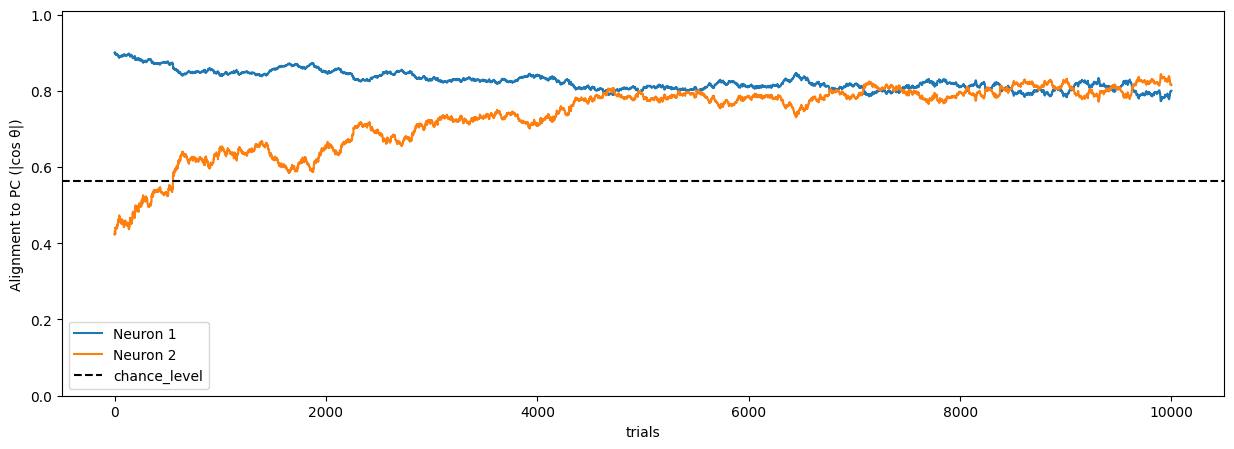

after second phase: model.W = [[-0.26223536 -0.23626361 -0.05171366 -0.09164256  0.03215372  0.20773408
  -0.0815698   0.30395475  0.3390779  -0.55746432]
 [ 0.05714932  0.34989093  0.37696312 -0.11774736  0.26184406  0.18820851
  -0.33508652  0.48323843 -0.24034848  0.23961042]]
model.V = [[0.         0.05630589]
 [0.05630589 0.        ]]
run  3
X_before
step    0 | order = [0 1] | best|corr|= [0.157 0.05 ]
step 1000 | order = [0 1] | best|corr|= [0.123 0.07 ]
step 2000 | order = [0 1] | best|corr|= [0.11  0.092]
step 3000 | order = [0 1] | best|corr|= [0.11  0.101]
step 4000 | order = [1 0] | best|corr|= [0.09 0.13]
step 5000 | order = [1 0] | best|corr|= [0.09  0.138]
step 6000 | order = [1 0] | best|corr|= [0.097 0.142]
step 7000 | order = [1 0] | best|corr|= [0.096 0.15 ]
step 8000 | order = [1 0] | best|corr|= [0.089 0.163]
step 9000 | order = [1 0] | best|corr|= [0.092 0.168]
step 10000 | order = [1 0] | best|corr|= [0.092 0.177]


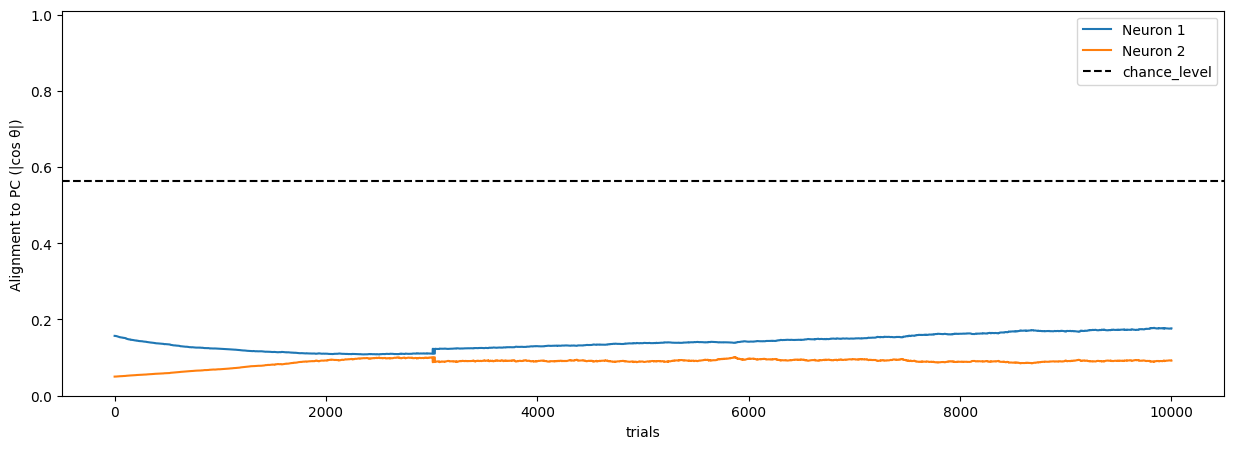

X_after
step    0 | order = [0 1] | best|corr|= [0.903 0.905]
step 1000 | order = [0 1] | best|corr|= [0.891 0.925]
step 2000 | order = [0 1] | best|corr|= [0.902 0.907]
step 3000 | order = [0 1] | best|corr|= [0.895 0.918]
step 4000 | order = [0 1] | best|corr|= [0.9   0.908]
step 5000 | order = [0 1] | best|corr|= [0.866 0.956]
step 6000 | order = [0 1] | best|corr|= [0.9   0.909]
step 7000 | order = [0 1] | best|corr|= [0.907 0.893]
step 8000 | order = [0 1] | best|corr|= [0.897 0.912]
step 9000 | order = [0 1] | best|corr|= [0.914 0.877]
step 10000 | order = [0 1] | best|corr|= [0.899 0.906]


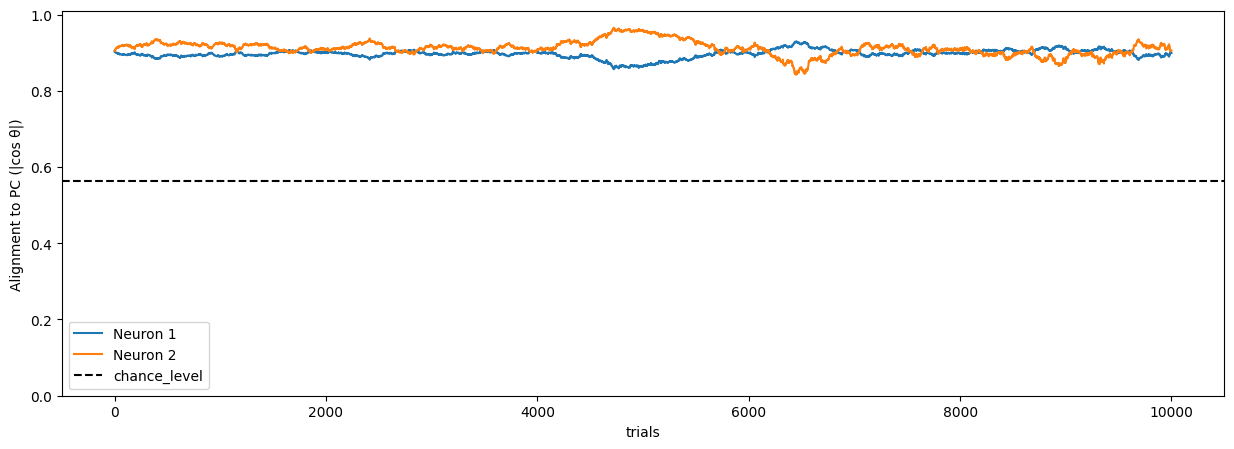

after second phase: model.W = [[-0.27584679  0.05268055  0.23664697  0.19381297  0.49900327  0.3567877
  -0.16470574  0.40540534  0.30309214 -0.38691654]
 [ 0.04243396  0.56465918  0.71085113 -0.08517362  0.13233361  0.00781655
  -0.22763097 -0.1570735  -0.16126601  0.14962228]]
model.V = [[ 0.         -0.06760083]
 [-0.06760083  0.        ]]
run  4
X_before
step    0 | order = [0 1] | best|corr|= [0.123 0.108]
step 1000 | order = [0 1] | best|corr|= [0.129 0.117]
step 2000 | order = [0 1] | best|corr|= [0.141 0.13 ]
step 3000 | order = [0 1] | best|corr|= [0.15  0.141]
step 4000 | order = [0 1] | best|corr|= [0.152 0.142]
step 5000 | order = [0 1] | best|corr|= [0.155 0.145]
step 6000 | order = [0 1] | best|corr|= [0.16  0.149]
step 7000 | order = [0 1] | best|corr|= [0.164 0.152]
step 8000 | order = [0 1] | best|corr|= [0.169 0.157]
step 9000 | order = [0 1] | best|corr|= [0.173 0.16 ]
step 10000 | order = [0 1] | best|corr|= [0.181 0.167]


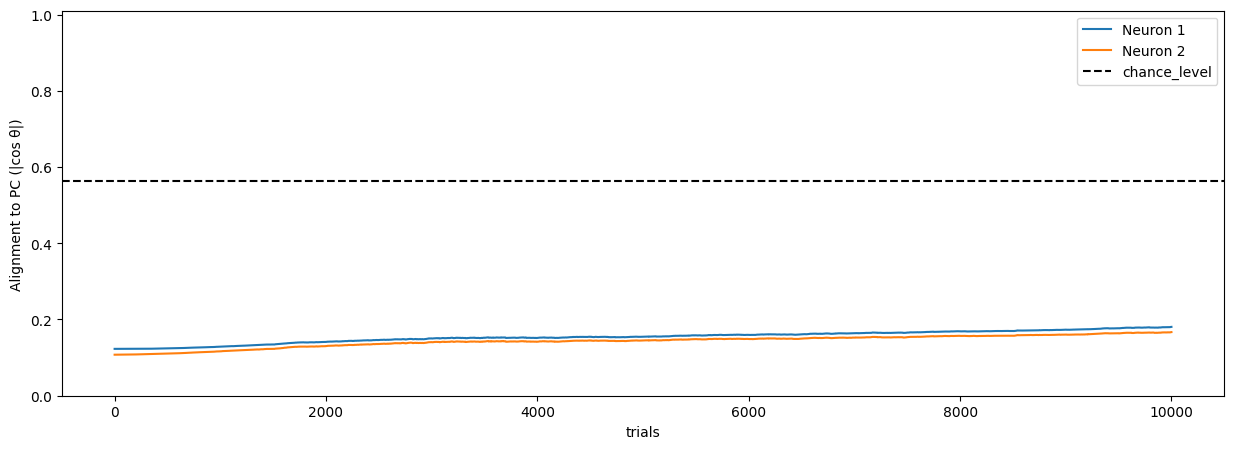

X_after
step    0 | order = [0 1] | best|corr|= [0.895 0.916]
step 1000 | order = [0 1] | best|corr|= [0.72  0.953]
step 2000 | order = [0 1] | best|corr|= [0.757 0.946]
step 3000 | order = [0 1] | best|corr|= [0.717 0.952]
step 4000 | order = [0 1] | best|corr|= [0.761 0.943]
step 5000 | order = [0 1] | best|corr|= [0.732 0.948]
step 6000 | order = [0 1] | best|corr|= [0.722 0.949]
step 7000 | order = [0 1] | best|corr|= [0.747 0.943]
step 8000 | order = [0 1] | best|corr|= [0.762 0.94 ]
step 9000 | order = [0 1] | best|corr|= [0.725 0.946]
step 10000 | order = [0 1] | best|corr|= [0.777 0.935]


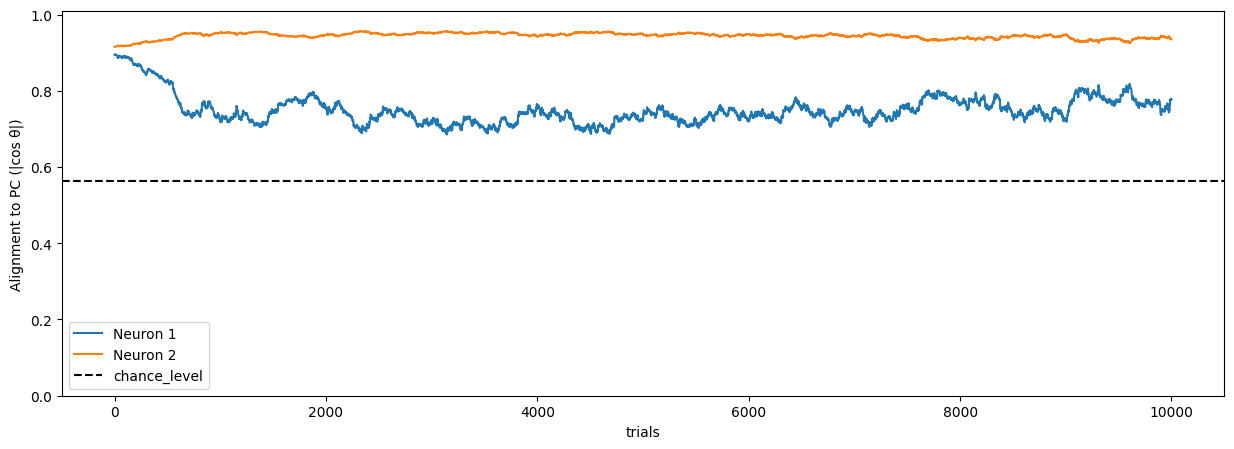

after second phase: model.W = [[ 0.08102231 -0.18215093  0.26867409  0.28442496  0.50695415  0.17153483
  -0.5901434   0.15405402 -0.28421533  0.14781119]
 [ 0.45072768  0.44656671 -0.09191817  0.181234   -0.07362568 -0.23914029
   0.09553182 -0.07217169 -0.21754745  0.63088398]]
model.V = [[0.        0.2186996]
 [0.2186996 0.       ]]
run  5
X_before
step    0 | order = [1 0] | best|corr|= [0.138 0.182]
step 1000 | order = [1 0] | best|corr|= [0.175 0.074]
step 2000 | order = [1 0] | best|corr|= [0.23  0.075]
step 3000 | order = [1 0] | best|corr|= [0.252 0.1  ]
step 4000 | order = [1 0] | best|corr|= [0.246 0.116]
step 5000 | order = [1 0] | best|corr|= [0.246 0.124]
step 6000 | order = [1 0] | best|corr|= [0.239 0.131]
step 7000 | order = [1 0] | best|corr|= [0.227 0.136]
step 8000 | order = [1 0] | best|corr|= [0.212 0.14 ]
step 9000 | order = [1 0] | best|corr|= [0.216 0.145]
step 10000 | order = [1 0] | best|corr|= [0.204 0.152]


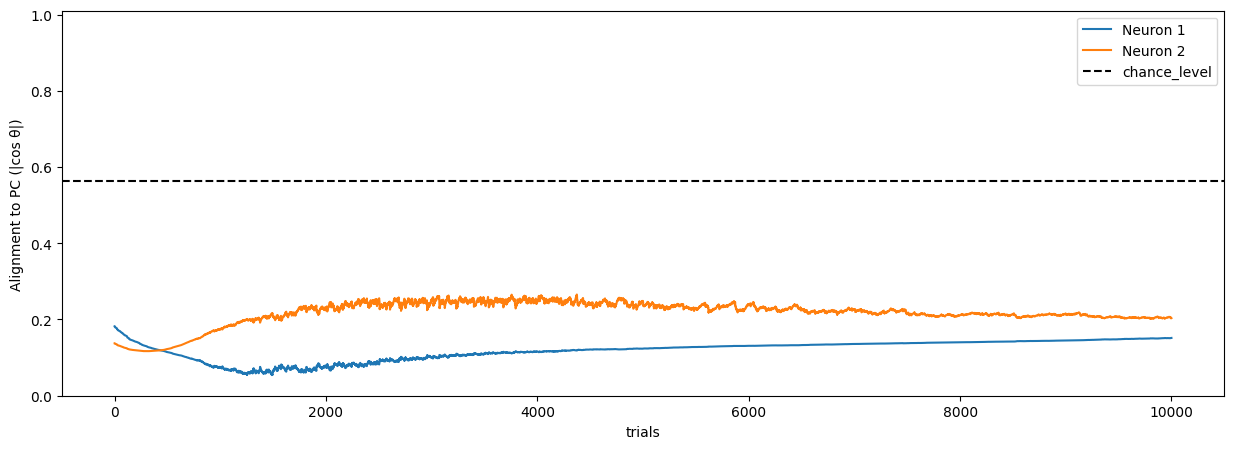

X_after
step    0 | order = [1 0] | best|corr|= [0.963 0.967]
step 1000 | order = [1 0] | best|corr|= [0.983 1.   ]
step 2000 | order = [1 0] | best|corr|= [0.982 1.   ]
step 3000 | order = [1 0] | best|corr|= [0.986 0.994]
step 4000 | order = [1 0] | best|corr|= [0.983 0.996]
step 5000 | order = [1 0] | best|corr|= [0.981 0.996]
step 6000 | order = [1 0] | best|corr|= [0.988 0.98 ]
step 7000 | order = [1 0] | best|corr|= [0.988 0.976]
step 8000 | order = [1 0] | best|corr|= [0.985 0.982]
step 9000 | order = [1 0] | best|corr|= [0.993 0.951]
step 10000 | order = [1 0] | best|corr|= [0.986 0.975]


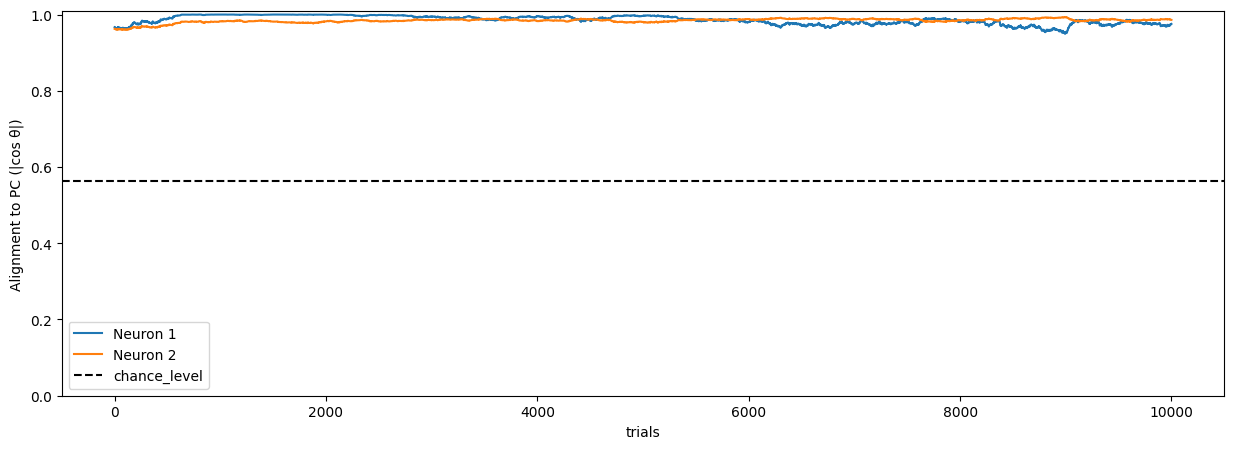

after second phase: model.W = [[-0.40254894 -0.24546432 -0.1711935   0.00404332  0.06930369  0.1490615
   0.15995273 -0.11055211  0.18761818 -0.74452661]
 [-0.1026446   0.07647194  0.157389   -0.13990541  0.33338772  0.37820928
  -0.44126229  0.09342953 -0.49608875 -0.04162698]]
model.V = [[ 0.         -0.00059506]
 [-0.00059506  0.        ]]
run  6
X_before
step    0 | order = [1 0] | best|corr|= [0.024 0.03 ]
step 1000 | order = [1 0] | best|corr|= [0.026 0.032]
step 2000 | order = [1 0] | best|corr|= [0.027 0.033]
step 3000 | order = [1 0] | best|corr|= [0.028 0.035]
step 4000 | order = [1 0] | best|corr|= [0.03  0.037]
step 5000 | order = [1 0] | best|corr|= [0.031 0.039]
step 6000 | order = [1 0] | best|corr|= [0.033 0.042]
step 7000 | order = [1 0] | best|corr|= [0.035 0.045]
step 8000 | order = [1 0] | best|corr|= [0.037 0.048]
step 9000 | order = [1 0] | best|corr|= [0.039 0.052]
step 10000 | order = [1 0] | best|corr|= [0.041 0.056]


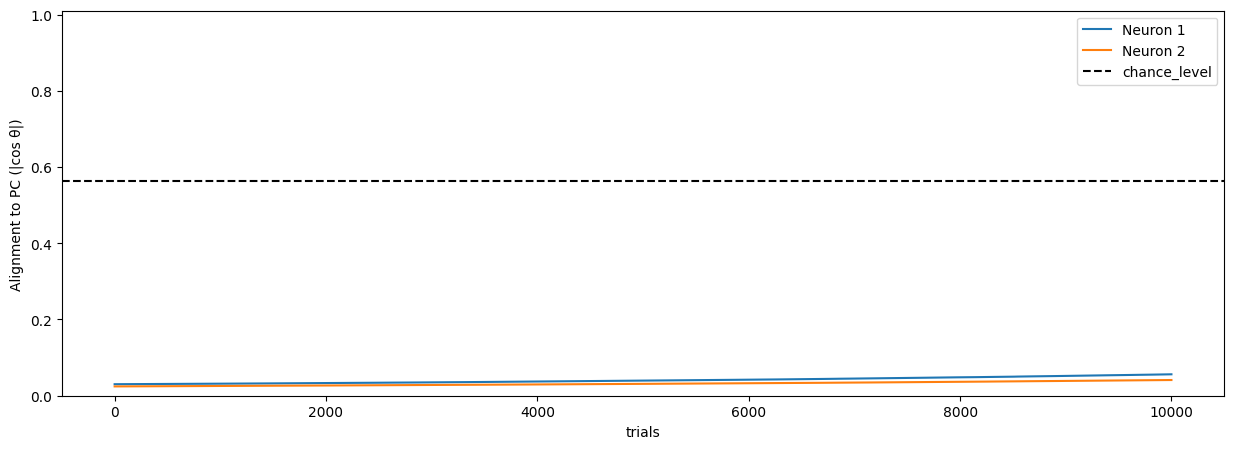

X_after
step    0 | order = [1 0] | best|corr|= [0.998 1.   ]
step 1000 | order = [1 0] | best|corr|= [0.994 0.999]
step 2000 | order = [1 0] | best|corr|= [0.988 0.996]
step 3000 | order = [1 0] | best|corr|= [0.98  0.991]
step 4000 | order = [1 0] | best|corr|= [0.971 0.985]
step 5000 | order = [1 0] | best|corr|= [0.963 0.982]
step 6000 | order = [1 0] | best|corr|= [0.953 0.978]
step 7000 | order = [1 0] | best|corr|= [0.945 0.974]
step 8000 | order = [1 0] | best|corr|= [0.944 0.975]
step 9000 | order = [1 0] | best|corr|= [0.938 0.974]
step 10000 | order = [1 0] | best|corr|= [0.945 0.98 ]


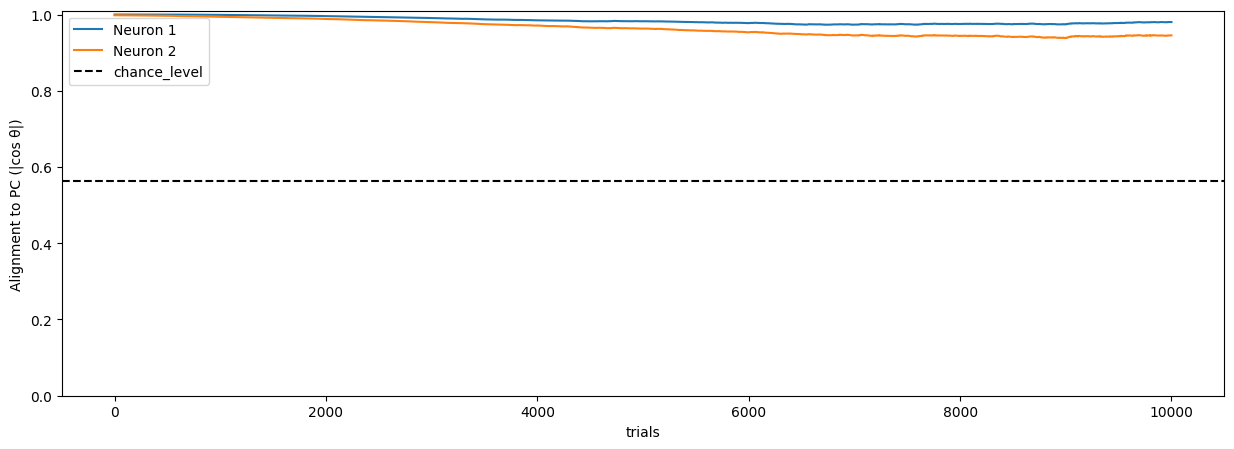

after second phase: model.W = [[ 0.36771661  0.43368133 -0.03963565 -0.25254029  0.04641394  0.11517993
  -0.00130241  0.16226472  0.73295441  0.15233842]
 [-0.21985328 -0.3936773  -0.04593302  0.14104712 -0.1562271   0.54907409
  -0.62156478 -0.05782765 -0.19191081  0.11453695]]
model.V = [[0.         0.39015711]
 [0.39015711 0.        ]]
run  7
X_before
step    0 | order = [1 0] | best|corr|= [0.155 0.052]
step 1000 | order = [1 0] | best|corr|= [0.174 0.032]
step 2000 | order = [1 0] | best|corr|= [0.202 0.03 ]
step 3000 | order = [1 0] | best|corr|= [0.206 0.032]
step 4000 | order = [1 0] | best|corr|= [0.206 0.033]
step 5000 | order = [1 0] | best|corr|= [0.207 0.034]
step 6000 | order = [1 0] | best|corr|= [0.206 0.036]
step 7000 | order = [1 0] | best|corr|= [0.206 0.038]
step 8000 | order = [1 0] | best|corr|= [0.205 0.04 ]
step 9000 | order = [1 0] | best|corr|= [0.208 0.041]
step 10000 | order = [1 0] | best|corr|= [0.206 0.045]


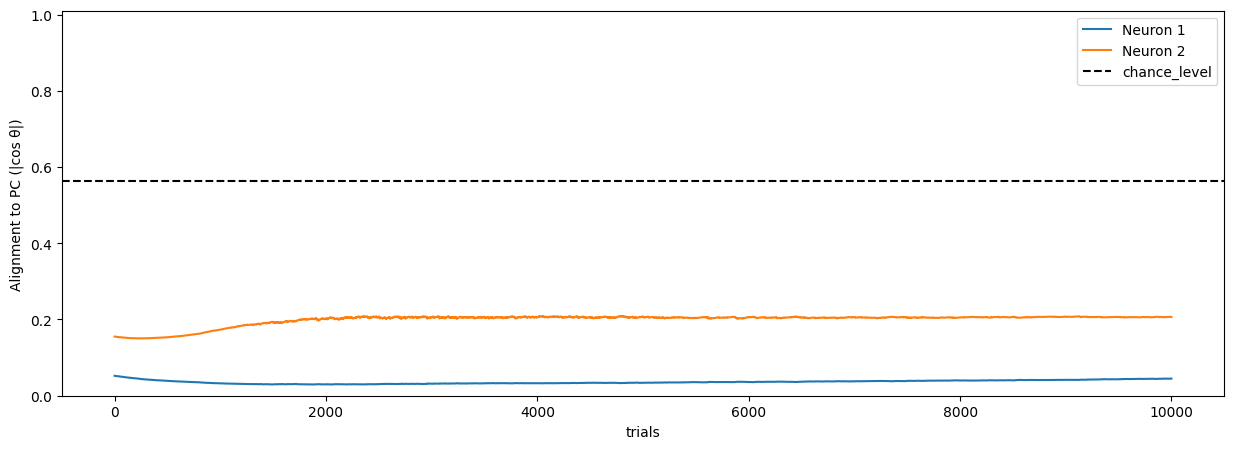

X_after
step    0 | order = [1 0] | best|corr|= [0.933 0.89 ]
step 1000 | order = [1 0] | best|corr|= [0.933 0.979]
step 2000 | order = [1 0] | best|corr|= [0.93 0.99]
step 3000 | order = [1 0] | best|corr|= [0.928 1.   ]
step 4000 | order = [1 0] | best|corr|= [0.924 1.   ]
step 5000 | order = [1 0] | best|corr|= [0.921 0.994]
step 6000 | order = [1 0] | best|corr|= [0.918 0.981]
step 7000 | order = [1 0] | best|corr|= [0.915 0.972]
step 8000 | order = [1 0] | best|corr|= [0.911 0.967]
step 9000 | order = [1 0] | best|corr|= [0.91  0.923]
step 10000 | order = [1 0] | best|corr|= [0.906 0.938]


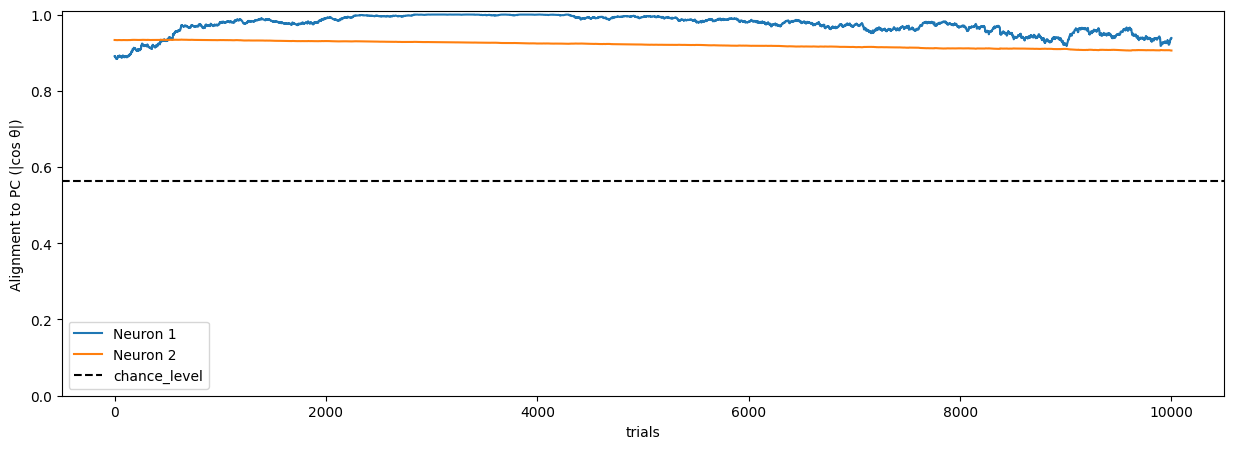

after second phase: model.W = [[ 0.20264192  0.47971319 -0.11065893 -0.08087466 -0.23265674 -0.32909467
  -0.31515155  0.02459908 -0.04449379  0.64227537]
 [ 0.07885618 -0.23659411  0.01722313  0.06363782  0.5226702   0.14286471
   0.44067729 -0.53230727  0.0492602   0.23108438]]
model.V = [[0.        0.0664724]
 [0.0664724 0.       ]]
run  8
X_before
step    0 | order = [1 0] | best|corr|= [0.092 0.147]
step 1000 | order = [1 0] | best|corr|= [0.093 0.158]
step 2000 | order = [1 0] | best|corr|= [0.097 0.164]
step 3000 | order = [1 0] | best|corr|= [0.101 0.171]
step 4000 | order = [1 0] | best|corr|= [0.104 0.182]
step 5000 | order = [1 0] | best|corr|= [0.108 0.191]
step 6000 | order = [1 0] | best|corr|= [0.113 0.192]
step 7000 | order = [1 0] | best|corr|= [0.117 0.199]
step 8000 | order = [1 0] | best|corr|= [0.12  0.209]
step 9000 | order = [1 0] | best|corr|= [0.124 0.214]
step 10000 | order = [1 0] | best|corr|= [0.129 0.216]


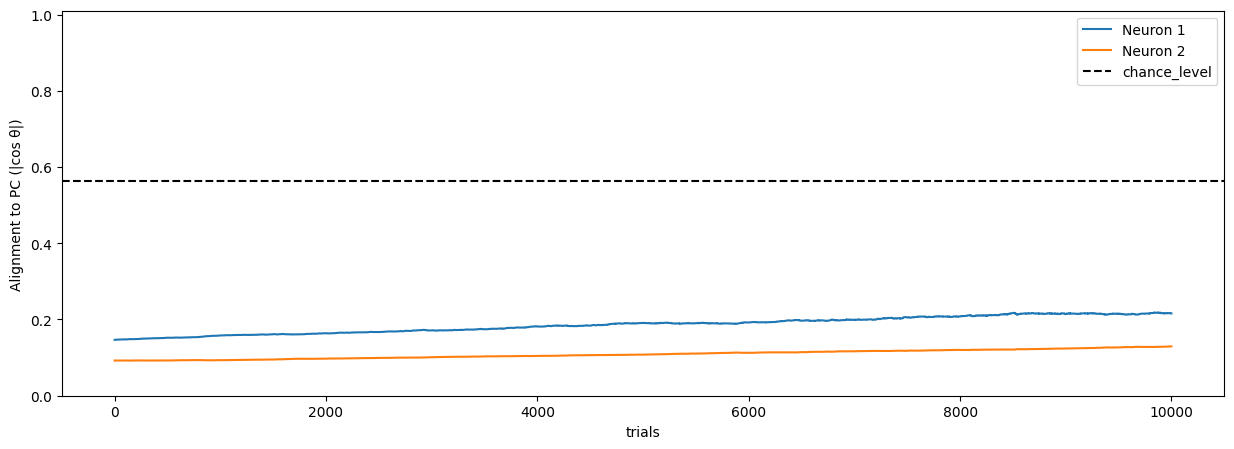

X_after
step    0 | order = [1 0] | best|corr|= [0.681 0.839]
step 1000 | order = [1 0] | best|corr|= [0.765 0.672]
step 2000 | order = [1 0] | best|corr|= [0.754 0.697]
step 3000 | order = [1 0] | best|corr|= [0.776 0.64 ]
step 4000 | order = [1 0] | best|corr|= [0.761 0.674]
step 5000 | order = [0 1] | best|corr|= [0.672 0.767]
step 6000 | order = [0 1] | best|corr|= [0.696 0.724]
step 7000 | order = [1 0] | best|corr|= [0.767 0.647]
step 8000 | order = [0 1] | best|corr|= [0.701 0.718]
step 9000 | order = [0 1] | best|corr|= [0.702 0.719]
step 10000 | order = [0 1] | best|corr|= [0.704 0.717]


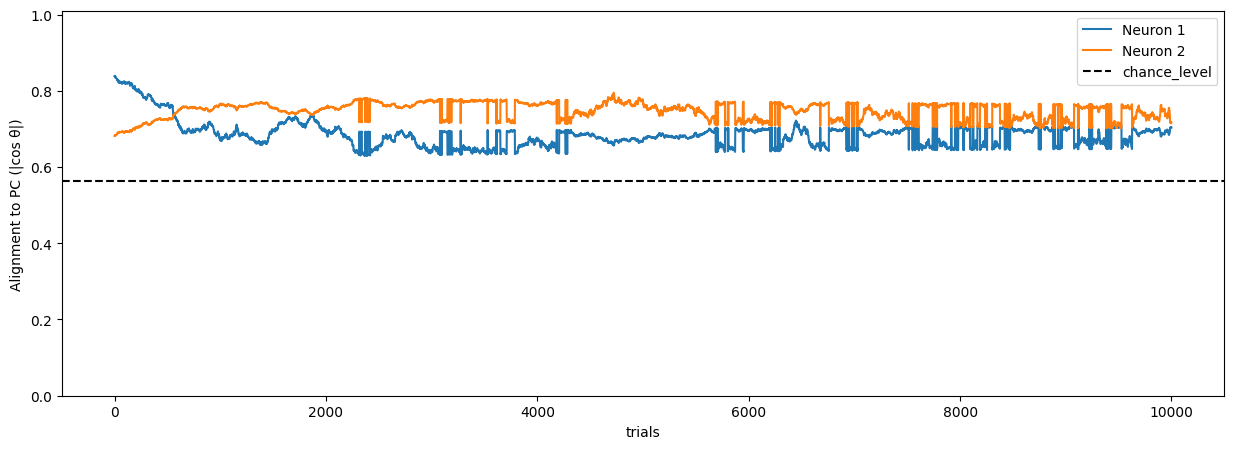

after second phase: model.W = [[ 0.33339314 -0.003015    0.00435777  0.06394459 -0.22074452 -0.31467984
   0.16974671 -0.31825787 -0.29866686  0.7153672 ]
 [ 0.03017004  0.03121982  0.10981611  0.14227583 -0.02814655  0.43695761
  -0.29142062  0.64251529 -0.09075749  0.51014702]]
model.V = [[0.         0.09151032]
 [0.09151032 0.        ]]
run  9
X_before
step    0 | order = [0 1] | best|corr|= [0.082 0.05 ]
step 1000 | order = [0 1] | best|corr|= [0.09  0.023]
step 2000 | order = [1 0] | best|corr|= [0.089 0.061]
step 3000 | order = [1 0] | best|corr|= [0.11 0.1 ]
step 4000 | order = [1 0] | best|corr|= [0.121 0.108]
step 5000 | order = [1 0] | best|corr|= [0.127 0.106]
step 6000 | order = [1 0] | best|corr|= [0.125 0.094]
step 7000 | order = [1 0] | best|corr|= [0.126 0.086]
step 8000 | order = [1 0] | best|corr|= [0.128 0.08 ]
step 9000 | order = [1 0] | best|corr|= [0.129 0.074]
step 10000 | order = [1 0] | best|corr|= [0.13  0.068]


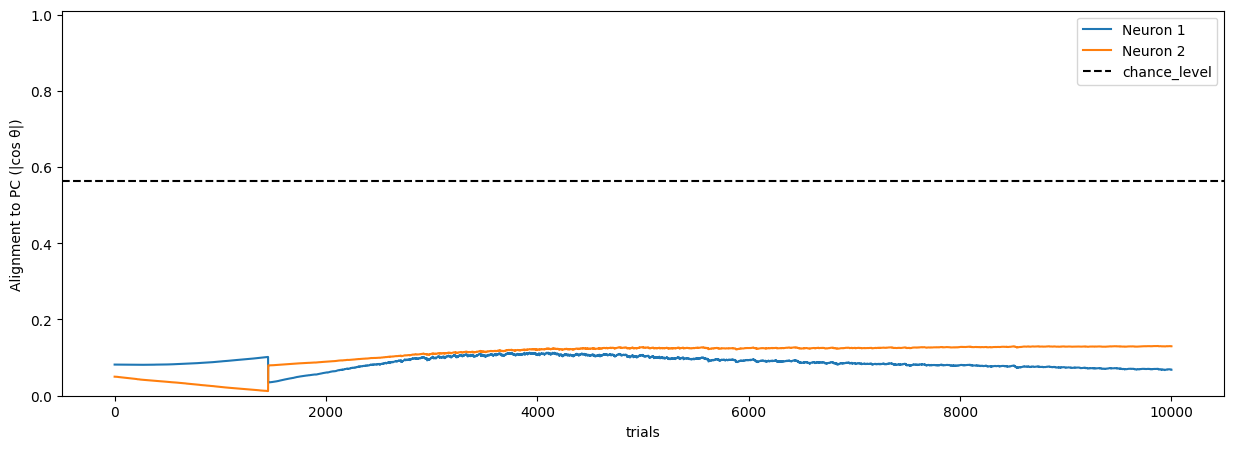

X_after
step    0 | order = [1 0] | best|corr|= [0.614 0.979]
step 1000 | order = [1 0] | best|corr|= [0.619 0.995]
step 2000 | order = [1 0] | best|corr|= [0.623 0.999]
step 3000 | order = [1 0] | best|corr|= [0.625 1.   ]
step 4000 | order = [1 0] | best|corr|= [0.626 0.999]
step 5000 | order = [1 0] | best|corr|= [0.625 0.977]
step 6000 | order = [1 0] | best|corr|= [0.624 0.976]
step 7000 | order = [1 0] | best|corr|= [0.625 0.968]
step 8000 | order = [1 0] | best|corr|= [0.625 0.939]
step 9000 | order = [1 0] | best|corr|= [0.625 0.925]
step 10000 | order = [1 0] | best|corr|= [0.625 0.892]


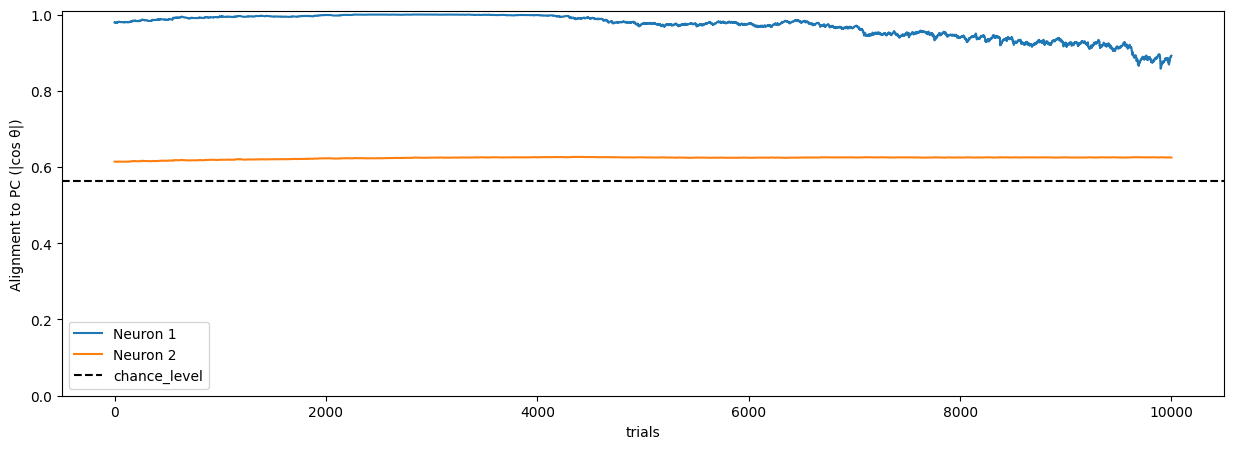

after second phase: model.W = [[-0.36710293 -0.0629746   0.30901602  0.09063716  0.03098517  0.41004095
  -0.09325292  0.3378151   0.19344528 -0.61434443]
 [-0.00988907 -0.21408019 -0.36480218 -0.67930373  0.09584614  0.25448878
  -0.16514856  0.05020205 -0.12402549  0.34345072]]
model.V = [[0.         0.14287216]
 [0.14287216 0.        ]]
run 10
X_before
step    0 | order = [1 0] | best|corr|= [0.006 0.149]
step 1000 | order = [1 0] | best|corr|= [0.007 0.15 ]
step 2000 | order = [1 0] | best|corr|= [0.008 0.156]
step 3000 | order = [1 0] | best|corr|= [0.009 0.165]
step 4000 | order = [1 0] | best|corr|= [0.01  0.176]
step 5000 | order = [1 0] | best|corr|= [0.011 0.185]
step 6000 | order = [1 0] | best|corr|= [0.012 0.195]
step 7000 | order = [1 0] | best|corr|= [0.013 0.202]
step 8000 | order = [1 0] | best|corr|= [0.014 0.207]
step 9000 | order = [1 0] | best|corr|= [0.014 0.211]
step 10000 | order = [1 0] | best|corr|= [0.015 0.214]


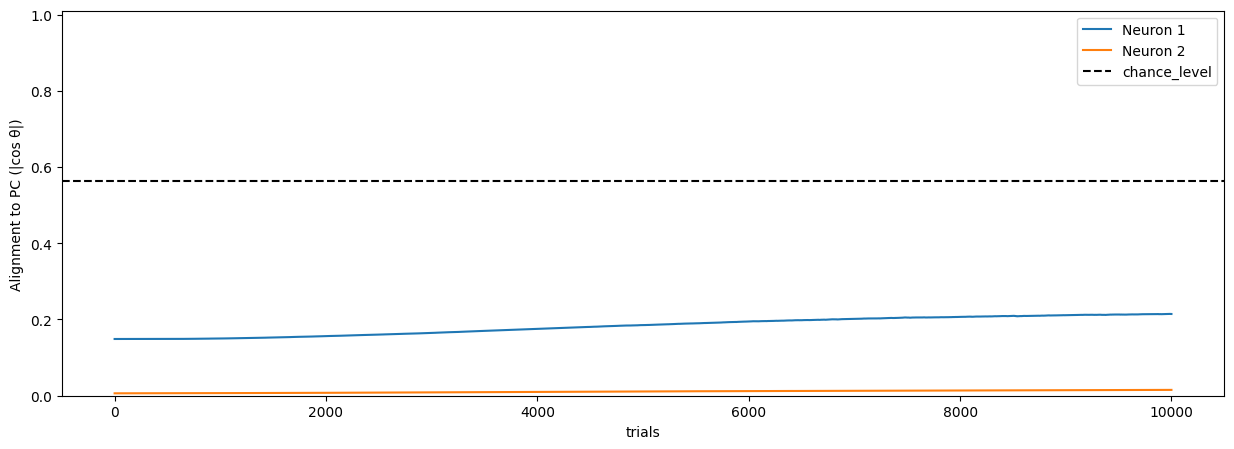

X_after
step    0 | order = [1 0] | best|corr|= [0.401 0.997]
step 1000 | order = [1 0] | best|corr|= [0.51  0.998]
step 2000 | order = [1 0] | best|corr|= [0.593 0.998]
step 3000 | order = [1 0] | best|corr|= [0.686 0.999]
step 4000 | order = [1 0] | best|corr|= [0.75  0.999]
step 5000 | order = [1 0] | best|corr|= [0.786 0.999]
step 6000 | order = [1 0] | best|corr|= [0.863 1.   ]
step 7000 | order = [1 0] | best|corr|= [0.917 1.   ]
step 8000 | order = [1 0] | best|corr|= [0.931 1.   ]
step 9000 | order = [1 0] | best|corr|= [0.977 1.   ]
step 10000 | order = [1 0] | best|corr|= [0.969 1.   ]


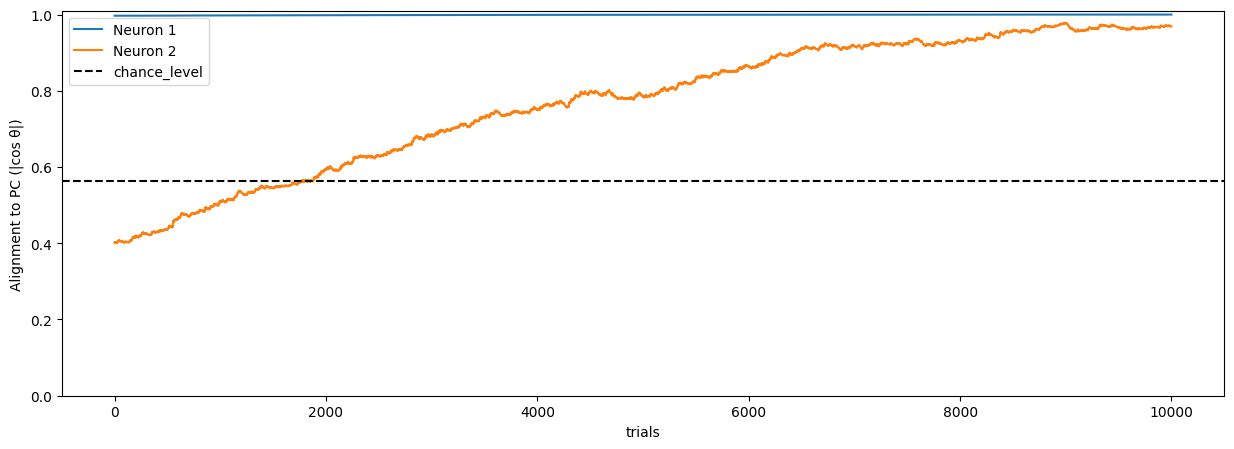

after second phase: model.W = [[ 0.55287275  0.11921759 -0.08205095 -0.12869895 -0.24162663 -0.03119437
  -0.1372976  -0.20257521 -0.42103675 -0.58195782]
 [ 0.17205683 -0.21941081 -0.39548593  0.39000974  0.06252629 -0.41901222
   0.42063525 -0.34658429 -0.09287536  0.33871918]]
model.V = [[ 0.         -0.07962466]
 [-0.07962466  0.        ]]


<Figure size 640x480 with 0 Axes>

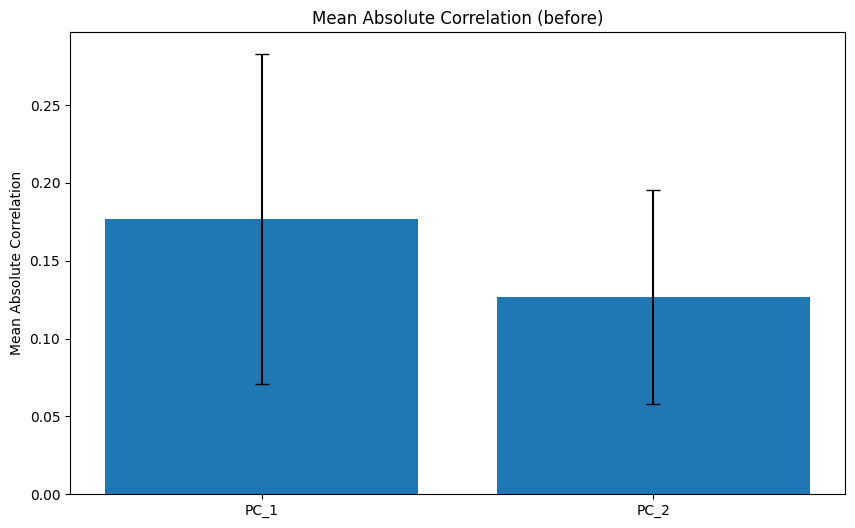

<Figure size 640x480 with 0 Axes>

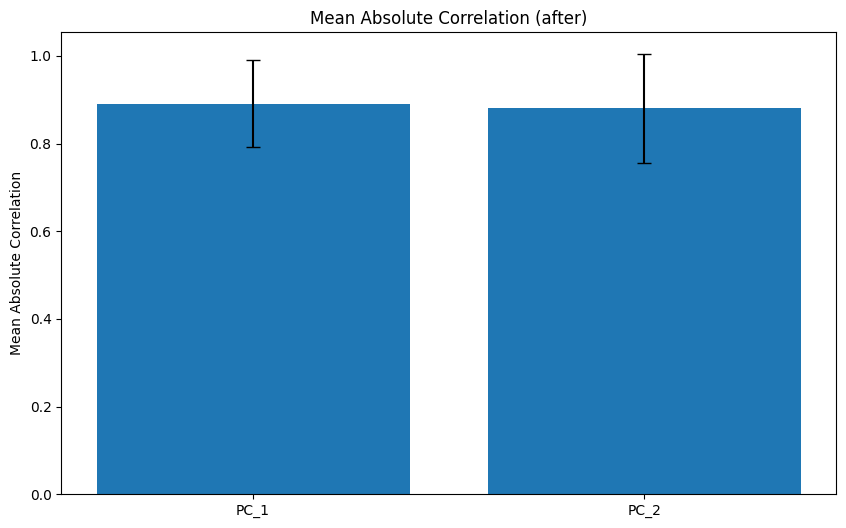

In [7]:
leen_model  = LeenCompletePCA(**model_paras)

two_phase_training_testing(leen_model, X_before, X_after, m, model_paras_after = None, runs = 10, graph = True)

In [8]:
from hebbian.utils import pca_topk
from scipy.stats import pearsonr
from hebbian.utils import best_match_align_timeseries



def random_projection_chance_corr1(X, n_samples=1000, seed=None):
    """
    Calculate the expected absolute correlation between a random projection 
    of X and the PC projections of X.
    
    Parameters
    ----------
    X : array-like, shape (n_samples, n_features)
        Input data
    n_samples : int, default=1000
        Number of random vectors to sample for Monte Carlo estimation
    seed : int or None
        Random seed
        
    Returns
    -------
    expected_corr : float
        Expected absolute correlation between random projection and PC projections
    std_corr : float
        Standard deviation of correlations (for reference)
    """
    X = np.asarray(X, dtype=float)
    n, d = X.shape
    
    # Center the data
    Xc = X - X.mean(axis=0, keepdims=True)
    
    # Get PCs
    _, _, PC_scores = pca_topk(X, d, center=True)
    print(f"shape of PC_scores: {PC_scores.shape}")
    
    # Sample random unit vectors
    rng = np.random.default_rng(seed)
    correlations = []
    
    for _ in range(n_samples):
        # Random unit vector in d-dimensional space
        w = rng.normal(size=d)
        w = w / (np.linalg.norm(w) + 1e-12)
        
        # Project X onto random direction
        y_random = Xc @ w
        
        # Compute correlation with each PC
        pc_corrs = []
        # print(f"shape of y_random: {y_random.shape}")
        
        # for j in range(min(d, PC_scores.shape[1])):
        # for j in range(2):
        # calculate the covariance between y_random and PC_scores[:, 0]
        cov = np.cov(y_random, PC_scores[:, 0])
        # pc_corrs.append(abs(r))
        pc_corrs.append(abs(cov[0, 1]))

        
        # Take max correlation (best match, like Hungarian algorithm does)
        correlations.append(max(pc_corrs))
    
    return np.mean(correlations), np.std(correlations)


def random_projection_chance_corr(X, m=2, n_samples=1000, metric="corr", absolute=True, seed=None):
    """
    Calculate the expected absolute correlation between random projections 
    of X and the PC projections of X, using the same matching procedure
    as the actual analysis (best_match_align_timeseries).
    
    This generates m random unit vectors, projects X onto them, and uses
    Hungarian matching to find optimal alignment with PCs, just like the
    real analysis does.
    
    Parameters
    ----------
    X : array-like, shape (n_samples, n_features)
        Input data
    m : int, default=2
        Number of random projections (should match output_dim of your model)
    n_samples : int, default=1000
        Number of random vector sets to sample for Monte Carlo estimation
    metric : {"corr", "cosine"}, default="corr"
        Metric to use (should match what you use in best_match_align_timeseries)
    absolute : bool, default=True
        Whether to use absolute correlations (should match your usage)
    seed : int or None
        Random seed
        
    Returns
    -------
    expected_corr : float
        Expected absolute correlation after optimal matching
    std_corr : float
        Standard deviation of correlations (for reference)
    all_corrs : ndarray, shape (n_samples, m)
        All correlation values from each trial (for distribution analysis)
    """
    X = np.asarray(X, dtype=float)
    n, d = X.shape
    
    # Center the data
    Xc = X - X.mean(axis=0, keepdims=True)
    
    # Get PC scores (top m PCs)
    _, _, PC_scores = pca_topk(X, d, center=True)
    PC_scores_m = PC_scores[:, :m]  # Use only top m PCs
    
    # Sample random projections
    rng = np.random.default_rng(seed)
    all_similarities = []
    
    for trial in range(n_samples):
        # Generate m random unit vectors in d-dimensional space
        W_random = rng.normal(size=(m, d))
        # Normalize each row to unit length
        W_random = W_random / (np.linalg.norm(W_random, axis=1, keepdims=True) + 1e-12)
        
        # Project X onto random directions: Y_random = Xc @ W_random.T
        # Shape: (n, d) @ (d, m) = (n, m)
        Y_random = Xc @ W_random.T
        
        # Use the same matching procedure as actual analysis
        perm, similarity, _, _ = best_match_align_timeseries(
            Y_random, PC_scores_m, 
            metric=metric, 
            absolute=absolute
        )
        
        # similarity is already the matched correlations
        all_similarities.append(similarity)
    
    all_similarities = np.array(all_similarities)  # Shape: (n_samples, m)
    
    # Compute statistics
    expected_corr = np.mean(all_similarities)
    std_corr = np.std(all_similarities)
    
    return expected_corr, std_corr, all_similarities


def random_projection_chance_corr_per_pc(X, m=2, n_samples=1000, metric="corr", absolute=True, seed=None):
    """
    Same as random_projection_chance_corr but returns per-PC statistics.
    
    Returns
    -------
    expected_corr_per_pc : ndarray, shape (m,)
        Expected correlation for each PC (after sorting by PC order)
    std_corr_per_pc : ndarray, shape (m,)
        Standard deviation for each PC
    """
    expected_corr, std_corr, all_similarities = random_projection_chance_corr(
        X, m, n_samples, metric, absolute, seed
    )
    
    # Sort similarities by PC order (they're already matched, but we want PC1, PC2, ...)
    # The similarities are already optimally matched, so we sort them
    all_similarities_sorted = np.sort(all_similarities, axis=1)  # Sort each row
    
    expected_corr_per_pc = np.mean(all_similarities_sorted, axis=0)
    std_corr_per_pc = np.std(all_similarities_sorted, axis=0)
    
    return expected_corr_per_pc, std_corr_per_pc, all_similarities_sorted



def analytical_chance_corr(input_dim):
    """
    Analytical approximation for expected correlation between random projection
    and PC projection, assuming isotropic data (all eigenvalues equal).
    
    This is a simplified case. For non-isotropic data, use random_projection_chance_corr.
    
    Parameters
    ----------
    input_dim : int
        Input dimensionality
        
    Returns
    -------
    float 
        Expected absolute correlation (approximate)
    """
    # For isotropic case, this reduces to the random vector chance level
    # For non-isotropic, it's more complex and depends on eigenvalue distribution
    return np.sqrt(2 / (np.pi * input_dim))

In [9]:
print(f"Analytical chance correlation: {analytical_chance_corr(N):.3f}")

Analytical chance correlation: 0.252


In [10]:
from hebbian.utils import generate_covariance_matrix
for i in range(2, 10, 1):
    N = i
    m = 2
    phi_deg = 45.0
    n_samples = 10001
    # get /sigma
    Sigma = np.array([[1.0, 0.2], [0.2, 1.0]])
    Sigma_rot = rotate_cov_nd(Sigma, np.deg2rad(phi_deg), axis1=0, axis2=1)

    X_before, X_after = instantiate_before_after_X(Sigma, Sigma_rot, N = N, seed=X_seed, n_samples=n_samples)
    print(f" input dimension = {N}")
    print(f"shape of X_before: {X_before.shape}")
    # In Y_aligned_training_testing_online or similar:
    expected_corr, std_corr = random_projection_chance_corr1(X_before, n_samples=1000)
    print(f"Expected chance correlation: {expected_corr:.3f} ± {std_corr:.3f}")

 input dimension = 2
shape of X_before: (10001, 2)
shape of PC_scores: (10001, 2)
Expected chance correlation: 0.768 ± 0.365
 input dimension = 3
shape of X_before: (10001, 3)
shape of PC_scores: (10001, 3)
Expected chance correlation: 0.606 ± 0.347
 input dimension = 4
shape of X_before: (10001, 4)
shape of PC_scores: (10001, 4)
Expected chance correlation: 0.514 ± 0.314
 input dimension = 5
shape of X_before: (10001, 5)
shape of PC_scores: (10001, 5)
Expected chance correlation: 0.455 ± 0.291
 input dimension = 6
shape of X_before: (10001, 6)
shape of PC_scores: (10001, 6)
Expected chance correlation: 0.412 ± 0.270
 input dimension = 7
shape of X_before: (10001, 7)
shape of PC_scores: (10001, 7)
Expected chance correlation: 0.374 ± 0.257
 input dimension = 8
shape of X_before: (10001, 8)
shape of PC_scores: (10001, 8)
Expected chance correlation: 0.339 ± 0.231
 input dimension = 9
shape of X_before: (10001, 9)
shape of PC_scores: (10001, 9)
Expected chance correlation: 0.331 ± 0.229


In [11]:
# In your notebook or analysis:

# Or get per-PC statistics
expected_per_pc, std_per_pc, _ = random_projection_chance_corr_per_pc(
    X_before, m=2, n_samples=1000
)
print(f"Expected chance correlation per PC: PC1={expected_per_pc[0]:.3f}, PC2={expected_per_pc[1]:.3f}")

Expected chance correlation per PC: PC1=0.675, PC2=0.947
